# EPIC — EXP033 False-Positive Study

Здесь мы **не обучаем новую модель**.

Берём уже обученный `EXP033 @ 10k`:

```text
NO BPE
base-level CNN
RF = 2053 bp
32-bp regional head
```

и исследуем **hard negatives** — регионы, где:

```text
target = 0
model score = высокий
```

Главная идея:

> Если самые сильные false positives по локальной DNA-последовательности очень похожи
> на настоящие positive regions и несут те же enriched sequence patterns, то часть ошибки
> может быть неразрешима простой sequence-only моделью из-за экспериментального состояния
> (chromatin / TF availability / cell state / stochastic initiation / label noise).

Но это **не будет доказательством**, что CNN уже оптимален. Это будет диагностикой:
есть ли ещё очевидный sequence signal, который текущая CNN не использует.

## Группы

Из полного validation holdout формируем по 10 000 регионов:

```text
HARD_FP
    самые высокие scores среди target=0

EASY_NEG
    самые низкие scores среди target=0

HIGH_TP
    самые высокие scores среди target=1

RANDOM_TP
    случайные positives, не вошедшие в HIGH_TP
```

## Что сравниваем

1. score distributions;
2. GC / N / sequence entropy;
3. 6-mer enrichment;
4. насколько совпадают enriched 6-mers у HARD_FP и HIGH_TP;
5. 4-mer similarity к positive centroid;
6. простая Logistic Regression:
   - HARD_FP vs EASY_NEG;
   - HARD_FP vs HIGH_TP.

Особенно интересен второй тест.

Если `HARD_FP vs HIGH_TP` даёт ROC-AUC около `0.5`, то простой локальный
sequence composition почти не отличает FP от настоящих positives.

Если AUC высокий, значит в последовательности остаётся заметный сигнал, который
текущая CNN потенциально ещё не использует.


In [1]:
from pathlib import Path
import copy
import gc
import math
import sys
import time
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

import torch
import torch.nn as nn
import torch_directml

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = next(
    candidate
    for candidate in (
        CURRENT_DIR,
        *CURRENT_DIR.parents,
    )
    if (candidate / "README.md").is_file()
    and (candidate / "src/ml_project").is_dir()
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

from ml_project.epic_baseline import (
    load_baseline_sequences,
)

from ml_project.epic_cnn import (
    DirectMLAdam,
    ProfileWindowConfig,
    ProfileWindowGenerator,
    create_cnn_presence_intensity,
)

from ml_project.epic_data import (
    load_split,
)

print("Project:", PROJECT_ROOT)


Project: D:\Projects\EPIC\EPIC


In [2]:
device = torch_directml.device()

print("DirectML device:", device)
print("GPU:", torch_directml.device_name(0))


DirectML device: privateuseone:0
GPU: AMD Radeon RX 6750 GRE 12GB 


In [3]:
# ============================================================
# DATA / WINDOW CONFIG
# ============================================================

split = load_split(
    PROJECT_ROOT
)

sequences, fasta_alphabet = (
    load_baseline_sequences(
        split
    )
)

train_contigs = tuple(
    sorted(
        set(
            split.intervals(
                "train"
            )[
                "contig"
            ].astype(str)
        )
    )
)

validation_contigs = tuple(
    sorted(
        set(
            split.intervals(
                "validation"
            )[
                "contig"
            ].astype(str)
        )
    )
)

assert set(
    train_contigs
).isdisjoint(
    validation_contigs
)

# Keep 2048-bp target so the regional grid is directly comparable
# with the recent regional experiments.
TARGET_LENGTH = 2048
CONTEXT_FLANK = 130

REGION_WIDTHS = (
    32,
)

PRIMARY_WIDTH = 32

BLOCK_SETTINGS_RF2053 = (
    (7, 1),
    (3, 2),
    (3, 4),
    (3, 8),
    (3, 16),
    (3, 32),
    (3, 64),
    (3, 128),
    (3, 256),
)

BACKBONE_RF_BP = (
    1
    + sum(
        2 * (kernel_size - 1) * dilation
        for kernel_size, dilation
        in BLOCK_SETTINGS_RF2053
    )
)

REGIONAL_UNION_RF_BP = (
    BACKBONE_RF_BP
    + PRIMARY_WIDTH
    - 1
)

assert BACKBONE_RF_BP == 2053
assert REGIONAL_UNION_RF_BP == 2084

assert TARGET_LENGTH % 32 == 0

profile_config = (
    ProfileWindowConfig(
        target_length=TARGET_LENGTH,
        context_flank=CONTEXT_FLANK,
        positive_branch_fraction=0.5,
    )
)

train_generator = (
    ProfileWindowGenerator(
        prepared_split=split,
        sequences=sequences,
        part="train",
        config=profile_config,
        seed=42,
    )
)

validation_generator = (
    ProfileWindowGenerator(
        prepared_split=split,
        sequences=sequences,
        part="validation",
        config=profile_config,
        seed=42,
    )
)

display(split.summary)

print("Train contigs:", len(train_contigs))
print(
    "Validation contigs:",
    len(validation_contigs),
)
print(
    "Input length:",
    TARGET_LENGTH
    + 2 * CONTEXT_FLANK,
)
print(
    "Target length:",
    TARGET_LENGTH,
)
print(
    "Region widths:",
    REGION_WIDTHS,
)

print(
    "Backbone RF:",
    BACKBONE_RF_BP,
    "bp",
)

print(
    "32-bp regional union RF:",
    REGIONAL_UNION_RF_BP,
    "bp",
)


,split,contigs,intervals_both_strands,whitelist_bp,position_strand_count,percent_of_all_positions,positive_positions,negative_positions,positive_percent
0,train,9,168998,114032080,228064160,59.316784,170443.0,227893717.0,0.074735
1,validation,3,60386,41903743,83807486,21.797334,56205.0,83751281.0,0.067064
2,test,3,54846,36306695,72613390,18.885882,NaN,NaN,NaN


Train contigs: 9
Validation contigs: 3
Input length: 2308
Target length: 2048
Region widths: (32,)
Backbone RF: 2053 bp
32-bp regional union RF: 2084 bp


In [4]:
# ============================================================
# REGIONAL HEAD ON TOP OF THE EXISTING BASE-LEVEL BACKBONE
# ============================================================


class RegionalPoolHead(
    nn.Module
):
    def __init__(
        self,
        in_channels,
    ):
        super().__init__()

        self.classifier = (
            nn.Sequential(
                nn.Conv1d(
                    2 * in_channels,
                    32,
                    1,
                ),
                nn.GELU(),
                nn.Conv1d(
                    32,
                    1,
                    1,
                ),
            )
        )

    def forward(
        self,
        target_features,
        width,
    ):
        B, C, L = (
            target_features.shape
        )

        if L % width != 0:
            raise ValueError(
                (L, width)
            )

        n_regions = (
            L // width
        )

        x = (
            target_features
            .reshape(
                B,
                C,
                n_regions,
                width,
            )
        )

        mean_features = (
            x.mean(
                dim=-1
            )
        )

        # RMS instead of max:
        # DirectML max backward caused scatter fallback/errors
        # in earlier regional experiments.
        rms_features = torch.sqrt(
            (
                x * x
            ).mean(
                dim=-1
            )
            + 1e-6
        )

        pooled = torch.cat(
            (
                mean_features,
                rms_features,
            ),
            dim=1,
        ).contiguous()

        return self.classifier(
            pooled
        )


class BaseLevelRegionalModel(
    nn.Module
):
    def __init__(self):
        super().__init__()

        self.base = (
            create_cnn_presence_intensity(
                block_settings=(
                    BLOCK_SETTINGS_RF2053
                )
            )
        )

        if not hasattr(
            self.base,
            "profile_head",
        ):
            raise AttributeError(
                "Expected base model to expose .profile_head"
            )

        self.backbone_channels = int(
            self.base
            .profile_head
            .in_channels
        )


        assert (
            len(
                self.base
                .backbone
                .blocks
            )
            == len(
                BLOCK_SETTINGS_RF2053
            )
        )

        # Old per-base profile head is NOT part of the new objective.
        # Freeze its parameters; its input is captured by a hook.
        for parameter in (
            self.base
            .profile_head
            .parameters()
        ):
            parameter.requires_grad = False

        self.heads = nn.ModuleDict({
            str(width): RegionalPoolHead(
                self.backbone_channels
            )
            for width in REGION_WIDTHS
        })

        self._captured_features = None

        self._feature_hook = (
            self.base
            .profile_head
            .register_forward_pre_hook(
                self._capture_backbone_features
            )
        )

    def _capture_backbone_features(
        self,
        module,
        inputs,
    ):
        self._captured_features = (
            inputs[0]
        )

    def forward(
        self,
        x,
    ):
        self._captured_features = None

        # Run the known DirectML-safe base model.
        # Its old outputs are intentionally ignored.
        _ = self.base(
            x
        )

        features = (
            self._captured_features
        )

        self._captured_features = None

        if features is None:
            raise RuntimeError(
                "Backbone feature hook did not fire."
            )

        expected_length = (
            TARGET_LENGTH
            + 2 * CONTEXT_FLANK
        )

        if (
            features.shape[-1]
            != expected_length
        ):
            raise ValueError(
                (
                    features.shape,
                    expected_length,
                )
            )

        target_features = (
            features[
                :,
                :,
                CONTEXT_FLANK:
                CONTEXT_FLANK
                + TARGET_LENGTH
            ]
            .contiguous()
        )

        outputs = {}

        for width in REGION_WIDTHS:
            outputs[
                width
            ] = (
                self.heads[
                    str(width)
                ](
                    target_features,
                    width,
                )
            )

        return outputs


def create_model():
    return BaseLevelRegionalModel()


model_cpu = create_model()

trainable_params = sum(
    p.numel()
    for p in model_cpu.parameters()
    if p.requires_grad
)

frozen_params = sum(
    p.numel()
    for p in model_cpu.parameters()
    if not p.requires_grad
)

print(
    "Backbone channels:",
    model_cpu.backbone_channels,
)

print(
    "Backbone theoretical RF:",
    BACKBONE_RF_BP,
    "bp",
)

print(
    "32-bp regional union RF:",
    REGIONAL_UNION_RF_BP,
    "bp",
)

print(
    "Trainable params:",
    f"{trainable_params:,}",
)

print(
    "Frozen old-head params:",
    f"{frozen_params:,}",
)

del model_cpu


Backbone channels: 32
Backbone theoretical RF: 2053 bp
32-bp regional union RF: 2084 bp
Trainable params: 67,521
Frozen old-head params: 66


In [5]:
# ============================================================
# TARGETS / LOSS / FORWARD HELPERS
# ============================================================


def make_region_targets_cpu(
    exact_target,
    base_weight,
    width,
):
    if (
        exact_target.device.type
        != "cpu"
    ):
        raise ValueError(
            "Expected CPU exact_target"
        )

    if (
        base_weight.device.type
        != "cpu"
    ):
        raise ValueError(
            "Expected CPU base_weight"
        )

    B = exact_target.shape[0]

    n_regions = (
        TARGET_LENGTH
        // width
    )

    target = (
        exact_target
        .float()
        .reshape(
            B,
            1,
            n_regions,
            width,
        )
        .amax(
            dim=-1
        )
    )

    valid = (
        (
            base_weight > 0
        )
        .reshape(
            B,
            1,
            n_regions,
            width,
        )
        .all(
            dim=-1
        )
        .float()
    )

    return (
        target.contiguous(),
        valid.contiguous(),
    )


def stable_region_bce(
    logits,
    targets,
    valid,
    *,
    max_pos_weight=32.0,
):
    targets = targets.to(
        dtype=logits.dtype
    )

    valid = valid.to(
        dtype=logits.dtype
    )

    with torch.no_grad():
        pos = (
            targets * valid
        ).sum()

        neg = (
            (1.0 - targets)
            * valid
        ).sum()

        pos_weight = torch.clamp(
            neg
            / torch.clamp(
                pos,
                min=1.0,
            ),
            min=1.0,
            max=max_pos_weight,
        )

    positive_term = (
        torch.clamp(
            -logits,
            min=0,
        )
        + torch.log1p(
            torch.exp(
                -torch.abs(
                    logits
                )
            )
        )
    )

    negative_term = (
        torch.clamp(
            logits,
            min=0,
        )
        + torch.log1p(
            torch.exp(
                -torch.abs(
                    logits
                )
            )
        )
    )

    element_loss = (
        targets
        * pos_weight
        * positive_term
        + (
            1.0 - targets
        )
        * negative_term
    )

    denom = torch.clamp(
        valid.sum(),
        min=1.0,
    )

    loss = (
        element_loss
        * valid
    ).sum() / denom

    return (
        loss,
        float(
            pos_weight
            .detach()
            .cpu()
            .item()
        ),
    )


def forward_both(
    model,
    x_both,
    batch_size,
):
    outputs_all = model(
        x_both
    )

    result = {}

    for width in REGION_WIDTHS:
        logits = outputs_all[
            width
        ]

        result[
            width
        ] = (
            logits[
                :batch_size
            ].contiguous(),
            logits[
                batch_size:
            ].contiguous(),
        )

    return result


In [6]:
# ============================================================
# FULL HOLDOUT TILE INDEX
# ============================================================

validation_tiles = (
    validation_generator
    .tile_index
    .copy()
)

print(
    "Tiles:",
    len(
        validation_tiles
    ),
)

print(
    "Position-strand:",
    int(
        validation_tiles[
            "allowed_position_strand"
        ].sum()
    ),
)

print(
    "Positives:",
    int(
        validation_tiles[
            "positive_positions"
        ].sum()
    ),
)

print(
    "Contigs:",
    validation_tiles[
        "contig"
    ].nunique(),
)


Tiles: 24700
Position-strand: 83807486
Positives: 56205
Contigs: 3


In [7]:
# ============================================================
# LOAD EXP033 @10K — ANALYSIS ONLY
# ============================================================

EXP033_RUN_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "experiments"
    / "CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY"
    / "run_001"
)

CHECKPOINT_PATH = (
    EXP033_RUN_DIR
    / "checkpoint_step_010000.pt"
)

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        CHECKPOINT_PATH
    )

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)

assert (
    checkpoint["experiment"]
    == "CNN-EXP-033"
)

assert (
    checkpoint["architecture"]
    == "baselevel_rf2053_dilated_cnn_regional_32_only"
)

assert int(
    checkpoint["backbone_rf_bp"]
) == 2053

validation_model = (
    create_model()
    .to(device)
)

validation_model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

validation_model.eval()

print("Loaded:", CHECKPOINT_PATH)
print("Step:", checkpoint["step"])
print("RF:", checkpoint["backbone_rf_bp"], "bp")


Loaded: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\checkpoint_step_010000.pt
Step: 10000
RF: 2053 bp


In [8]:
# ============================================================
# SCORE EVERY VALID 32-BP REGION ON THE FULL HOLDOUT
# ============================================================

REGION_WIDTH = 32
N_REGIONS = TARGET_LENGTH // REGION_WIDTH
EVAL_BATCH_SIZE = 8

def sigmoid_numpy(x):
    x = np.asarray(
        x,
        dtype=np.float64,
    )

    out = np.empty_like(x)

    positive = x >= 0

    out[positive] = (
        1.0
        / (
            1.0
            + np.exp(
                -x[positive]
            )
        )
    )

    exp_x = np.exp(
        x[~positive]
    )

    out[~positive] = (
        exp_x
        / (
            1.0
            + exp_x
        )
    )

    return out


score_chunks = []
target_chunks = []
tile_chunks = []
strand_chunks = []
region_chunks = []

started = time.perf_counter()
positions = 0

with warnings.catch_warnings(
    record=True
) as caught:

    warnings.simplefilter(
        "always"
    )

    with torch.no_grad():
        for batch_no, start in enumerate(
            range(
                0,
                len(validation_tiles),
                EVAL_BATCH_SIZE,
            ),
            1,
        ):
            selected = (
                validation_tiles.iloc[
                    start:
                    start + EVAL_BATCH_SIZE
                ]
            )

            batch = (
                validation_generator
                .make_batch(
                    selected
                )
            )

            B = len(selected)

            x_gpu = (
                batch
                .x_both_strands
                .to(device)
            )

            outputs = (
                forward_both(
                    validation_model,
                    x_gpu,
                    batch_size=B,
                )
            )

            plus_logits, minus_logits_reverse = (
                outputs[
                    REGION_WIDTH
                ]
            )

            plus_score = sigmoid_numpy(
                plus_logits
                .detach()
                .cpu()
                .numpy()
            )[:, 0, :]

            minus_score = sigmoid_numpy(
                minus_logits_reverse
                .detach()
                .cpu()
                .numpy()
            )[:, 0, ::-1]

            score = np.stack(
                (
                    plus_score,
                    minus_score,
                ),
                axis=1,
            )

            mask = (
                batch.mask
                .numpy()
                .astype(bool)
            )

            counts = (
                batch.count
                .numpy()
            )

            valid = (
                mask
                .reshape(
                    B,
                    2,
                    N_REGIONS,
                    REGION_WIDTH,
                )
                .all(axis=-1)
            )

            positive = (
                (
                    (counts > 0)
                    & mask
                )
                .reshape(
                    B,
                    2,
                    N_REGIONS,
                    REGION_WIDTH,
                )
                .any(axis=-1)
            )

            local_tile, strand, region = (
                np.nonzero(valid)
            )

            score_chunks.append(
                score[
                    local_tile,
                    strand,
                    region,
                ].astype(
                    np.float32
                )
            )

            target_chunks.append(
                positive[
                    local_tile,
                    strand,
                    region,
                ].astype(
                    np.bool_
                )
            )

            tile_chunks.append(
                (
                    start
                    + local_tile
                ).astype(
                    np.int32
                )
            )

            strand_chunks.append(
                strand.astype(
                    np.int8
                )
            )

            region_chunks.append(
                region.astype(
                    np.int16
                )
            )

            positions += int(
                mask.sum()
            )

            finished = (
                start + B
                >= len(
                    validation_tiles
                )
            )

            if (
                batch_no == 1
                or batch_no % 500 == 0
                or finished
            ):
                elapsed = (
                    time.perf_counter()
                    - started
                )

                print(
                    f"tiles="
                    f"{start + B:>5}"
                    f"/{len(validation_tiles)} "
                    f"valid_bp="
                    f"{positions:>9} "
                    f"positions/s="
                    f"{positions / elapsed:,.0f}"
                )

fallback = [
    str(w.message)
    for w in caught
    if "fall back"
    in str(
        w.message
    ).lower()
]

if fallback:
    raise RuntimeError(
        "DirectML fallback: "
        + " | ".join(
            fallback
        )
    )

scores_all = np.concatenate(
    score_chunks
)

targets_all = np.concatenate(
    target_chunks
)

tile_rows_all = np.concatenate(
    tile_chunks
)

strands_all = np.concatenate(
    strand_chunks
)

regions_all = np.concatenate(
    region_chunks
)

assert (
    scores_all.shape
    == targets_all.shape
    == tile_rows_all.shape
    == strands_all.shape
    == regions_all.shape
)

print()
print(
    "Valid 32-bp regions:",
    f"{len(scores_all):,}",
)

print(
    "Positive regions:",
    f"{int(targets_all.sum()):,}",
)

print(
    "Negative regions:",
    f"{int((~targets_all).sum()):,}",
)

print(
    "Prevalence:",
    f"{targets_all.mean():.6f}",
)


tiles=    8/24700 valid_bp=    23524 positions/s=109,837
tiles= 4000/24700 valid_bp= 13735464 positions/s=2,943,405
tiles= 8000/24700 valid_bp= 27763582 positions/s=3,056,250
tiles=12000/24700 valid_bp= 41193676 positions/s=3,067,454
tiles=16000/24700 valid_bp= 54896176 positions/s=3,102,618
tiles=20000/24700 valid_bp= 67811662 positions/s=3,092,915
tiles=24000/24700 valid_bp= 81734314 positions/s=3,129,269
tiles=24700/24700 valid_bp= 83807486 positions/s=3,119,144

Valid 32-bp regions: 2,560,380
Positive regions: 27,982
Negative regions: 2,532,398
Prevalence: 0.010929


In [9]:
# ============================================================
# SCORE DISTRIBUTIONS
# ============================================================

quantiles = (
    0.00,
    0.01,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.99,
    0.999,
    1.00,
)

distribution_rows = []

for group_name, mask in (
    (
        "negative",
        ~targets_all,
    ),
    (
        "positive",
        targets_all,
    ),
):
    values = (
        scores_all[
            mask
        ]
    )

    for q in quantiles:
        distribution_rows.append({
            "group": group_name,
            "quantile": q,
            "score": float(
                np.quantile(
                    values,
                    q,
                )
            ),
        })

score_distribution = (
    pd.DataFrame(
        distribution_rows
    )
)

display(
    score_distribution
)


,group,quantile,score
0,negative,0.000,0.000228
1,negative,0.010,0.005504
2,negative,0.100,0.022465
3,negative,0.250,0.057228
4,negative,0.500,0.188180
5,negative,0.750,0.481026
6,negative,0.900,0.744908
7,negative,0.990,0.948046
8,negative,0.999,0.988481
9,negative,1.000,0.999955


In [10]:
# ============================================================
# SELECT 4 DIAGNOSTIC GROUPS
# ============================================================

GROUP_N = 10_000
RNG = np.random.default_rng(
    42
)

negative_idx = np.flatnonzero(
    ~targets_all
)

positive_idx = np.flatnonzero(
    targets_all
)

assert len(negative_idx) >= 2 * GROUP_N
assert len(positive_idx) >= 2 * GROUP_N

negative_order = negative_idx[
    np.argsort(
        scores_all[
            negative_idx
        ],
        kind="mergesort",
    )
]

positive_order = positive_idx[
    np.argsort(
        -scores_all[
            positive_idx
        ],
        kind="mergesort",
    )
]

easy_neg_idx = (
    negative_order[
        :GROUP_N
    ]
)

hard_fp_idx = (
    negative_order[
        -GROUP_N:
    ][::-1]
)

high_tp_idx = (
    positive_order[
        :GROUP_N
    ]
)

remaining_positive = np.setdiff1d(
    positive_idx,
    high_tp_idx,
    assume_unique=False,
)

random_tp_idx = RNG.choice(
    remaining_positive,
    size=GROUP_N,
    replace=False,
)

group_index = {
    "HARD_FP": hard_fp_idx,
    "EASY_NEG": easy_neg_idx,
    "HIGH_TP": high_tp_idx,
    "RANDOM_TP": random_tp_idx,
}

selection_parts = []

for group_name, idx in (
    group_index.items()
):
    selection_parts.append(
        pd.DataFrame({
            "group": group_name,
            "catalog_index": idx,
            "score": scores_all[
                idx
            ],
            "target": targets_all[
                idx
            ],
            "tile_row": tile_rows_all[
                idx
            ],
            "strand_index": strands_all[
                idx
            ],
            "region_index": regions_all[
                idx
            ],
        })
    )

selection = pd.concat(
    selection_parts,
    ignore_index=True,
)

selection[
    "strand"
] = np.where(
    selection[
        "strand_index"
    ].to_numpy()
    == 0,
    "+",
    "-",
)

# Add tile metadata where available.
tile_meta_columns = [
    c
    for c in (
        "contig",
        "target_start",
        "target_end",
        "target_start_0based",
        "target_end_0based",
        "start",
        "end",
    )
    if c
    in validation_tiles.columns
]

for column in tile_meta_columns:
    selection[
        column
    ] = (
        validation_tiles
        .iloc[
            selection[
                "tile_row"
            ].to_numpy()
        ][
            column
        ]
        .to_numpy()
    )

# Only compute genomic region coordinates if the tile table
# exposes an explicitly named target start.
target_start_column = None

for candidate in (
    "target_start_0based",
    "target_start",
):
    if candidate in selection.columns:
        target_start_column = candidate
        break

if target_start_column is not None:
    selection[
        "region_start_0based"
    ] = (
        selection[
            target_start_column
        ].astype(
            np.int64
        )
        + selection[
            "region_index"
        ].astype(
            np.int64
        )
        * REGION_WIDTH
    )

    selection[
        "region_end_0based"
    ] = (
        selection[
            "region_start_0based"
        ]
        + REGION_WIDTH
    )

display(
    selection
    .groupby(
        "group"
    )
    .agg(
        n=(
            "score",
            "size",
        ),
        score_min=(
            "score",
            "min",
        ),
        score_median=(
            "score",
            "median",
        ),
        score_max=(
            "score",
            "max",
        ),
    )
)

print(
    "Validation tile columns:"
)

print(
    list(
        validation_tiles.columns
    )
)


,n,score_min,score_median,score_max
group,,,,
EASY_NEG,10000,0.000228,0.002790,0.003650
HARD_FP,10000,0.971415,0.981931,0.999955
HIGH_TP,10000,0.889411,0.954414,0.999933
RANDOM_TP,10000,0.008162,0.675394,0.889287


Validation tile columns:
['tile_id', 'contig', 'target_start', 'allowed_bp', 'positive_positions', 'count_sum', 'target_end', 'allowed_position_strand', 'negative_positions', 'q_positive', 'q_negative', 'q_mixture']


In [11]:
# ============================================================
# EXTRACT STRAND-ORIENTED DNA AROUND EACH SELECTED REGION
# ============================================================
# We use a 256-bp window centered on the 32-bp region.
# With CONTEXT_FLANK=130 this fits even for target-edge regions.

CONTEXT_BP = 256
HALF_CONTEXT = (
    CONTEXT_BP // 2
)

assert CONTEXT_BP % 2 == 0
assert HALF_CONTEXT <= CONTEXT_FLANK + 16

BASES = np.array(
    list(
        "ACGTN"
    )
)

selection = (
    selection
    .reset_index(
        drop=True
    )
)

selection[
    "seq_core32"
] = ""

selection[
    "seq_context256"
] = ""

tile_to_selection_rows = (
    selection
    .groupby(
        "tile_row"
    )
    .indices
)

unique_tile_rows = np.array(
    sorted(
        tile_to_selection_rows
        .keys()
    ),
    dtype=np.int64,
)

EXTRACT_BATCH_SIZE = 64

started = time.perf_counter()

for batch_start in range(
    0,
    len(unique_tile_rows),
    EXTRACT_BATCH_SIZE,
):
    tile_rows = (
        unique_tile_rows[
            batch_start:
            batch_start
            + EXTRACT_BATCH_SIZE
        ]
    )

    batch = (
        validation_generator
        .make_batch(
            validation_tiles
            .iloc[
                tile_rows
            ]
        )
    )

    x = (
        batch
        .x_both_strands
        .numpy()
    )

    B = len(
        tile_rows
    )

    tile_to_local = {
        int(tile_row): local
        for local, tile_row
        in enumerate(
            tile_rows
        )
    }

    for tile_row in tile_rows:
        local = (
            tile_to_local[
                int(tile_row)
            ]
        )

        for selection_row in (
            tile_to_selection_rows[
                int(tile_row)
            ]
        ):
            strand_index = int(
                selection.at[
                    selection_row,
                    "strand_index",
                ]
            )

            genomic_region = int(
                selection.at[
                    selection_row,
                    "region_index",
                ]
            )

            if strand_index == 0:
                oriented_row = local
                oriented_region = (
                    genomic_region
                )
            else:
                oriented_row = (
                    B + local
                )
                oriented_region = (
                    N_REGIONS
                    - 1
                    - genomic_region
                )

            core_start = (
                CONTEXT_FLANK
                + oriented_region
                * REGION_WIDTH
            )

            core_end = (
                core_start
                + REGION_WIDTH
            )

            center = (
                core_start
                + REGION_WIDTH // 2
            )

            context_start = (
                center
                - HALF_CONTEXT
            )

            context_end = (
                center
                + HALF_CONTEXT
            )

            if (
                context_start < 0
                or context_end
                > x.shape[-1]
            ):
                raise RuntimeError(
                    (
                        context_start,
                        context_end,
                        x.shape[-1],
                    )
                )

            core_codes = np.argmax(
                x[
                    oriented_row,
                    :,
                    core_start:
                    core_end,
                ],
                axis=0,
            )

            context_codes = np.argmax(
                x[
                    oriented_row,
                    :,
                    context_start:
                    context_end,
                ],
                axis=0,
            )

            selection.at[
                selection_row,
                "seq_core32",
            ] = "".join(
                BASES[
                    core_codes
                ]
            )

            selection.at[
                selection_row,
                "seq_context256",
            ] = "".join(
                BASES[
                    context_codes
                ]
            )

    done = min(
        batch_start
        + EXTRACT_BATCH_SIZE,
        len(
            unique_tile_rows
        ),
    )

    if (
        batch_start == 0
        or done % 2000 < EXTRACT_BATCH_SIZE
        or done
        == len(
            unique_tile_rows
        )
    ):
        print(
            f"tiles extracted="
            f"{done:,}/"
            f"{len(unique_tile_rows):,}"
        )

assert (
    selection[
        "seq_core32"
    ]
    .str.len()
    .eq(
        REGION_WIDTH
    )
    .all()
)

assert (
    selection[
        "seq_context256"
    ]
    .str.len()
    .eq(
        CONTEXT_BP
    )
    .all()
)

print(
    "Sequence extraction minutes:",
    round(
        (
            time.perf_counter()
            - started
        )
        / 60.0,
        2,
    ),
)


tiles extracted=64/14,710
tiles extracted=2,048/14,710
tiles extracted=4,032/14,710
tiles extracted=6,016/14,710
tiles extracted=8,000/14,710
tiles extracted=10,048/14,710
tiles extracted=12,032/14,710
tiles extracted=14,016/14,710
tiles extracted=14,710/14,710
Sequence extraction minutes: 0.12


In [12]:
# ============================================================
# BASIC SEQUENCE COMPOSITION
# ============================================================

def sequence_stats(
    seq
):
    n = len(seq)

    counts = {
        base: seq.count(base)
        for base in "ACGTN"
    }

    valid = (
        counts["A"]
        + counts["C"]
        + counts["G"]
        + counts["T"]
    )

    if valid > 0:
        gc = (
            counts["G"]
            + counts["C"]
        ) / valid
    else:
        gc = np.nan

    probs = np.array(
        [
            counts[b]
            for b in "ACGT"
        ],
        dtype=np.float64,
    )

    if probs.sum() > 0:
        probs = (
            probs
            / probs.sum()
        )

        nz = (
            probs > 0
        )

        entropy = float(
            -np.sum(
                probs[nz]
                * np.log2(
                    probs[nz]
                )
            )
        )
    else:
        entropy = np.nan

    return (
        gc,
        counts["N"] / n,
        entropy,
    )


core_stats = np.array(
    [
        sequence_stats(seq)
        for seq
        in selection[
            "seq_core32"
        ]
    ],
    dtype=np.float64,
)

context_stats = np.array(
    [
        sequence_stats(seq)
        for seq
        in selection[
            "seq_context256"
        ]
    ],
    dtype=np.float64,
)

selection[
    "gc_core32"
] = core_stats[:, 0]

selection[
    "n_fraction_core32"
] = core_stats[:, 1]

selection[
    "entropy_core32"
] = core_stats[:, 2]

selection[
    "gc_context256"
] = context_stats[:, 0]

selection[
    "n_fraction_context256"
] = context_stats[:, 1]

selection[
    "entropy_context256"
] = context_stats[:, 2]

composition_summary = (
    selection
    .groupby(
        "group",
        as_index=False,
    )
    .agg(
        n=(
            "score",
            "size",
        ),
        score_median=(
            "score",
            "median",
        ),
        gc_core32_mean=(
            "gc_core32",
            "mean",
        ),
        gc_context256_mean=(
            "gc_context256",
            "mean",
        ),
        n_context256_mean=(
            "n_fraction_context256",
            "mean",
        ),
        entropy_core32_mean=(
            "entropy_core32",
            "mean",
        ),
        entropy_context256_mean=(
            "entropy_context256",
            "mean",
        ),
    )
)

display(
    composition_summary
)


,group,n,score_median,gc_core32_mean,gc_context256_mean,n_context256_mean,entropy_core32_mean,entropy_context256_mean
0,EASY_NEG,10000,0.002790,0.300329,0.365598,0.003478,1.687344,1.895837
1,HARD_FP,10000,0.981931,0.461137,0.442487,0.000000,1.903761,1.970455
2,HIGH_TP,10000,0.954414,0.459688,0.435557,0.000000,1.904421,1.968115
3,RANDOM_TP,10000,0.675394,0.435831,0.421448,0.000005,1.891330,1.958505


In [13]:
# ============================================================
# DE-NOVO 6-MER ENRICHMENT
# ============================================================

from collections import Counter

K = 6
PSEUDOCOUNT = 1.0


def aggregate_kmers(
    seqs,
    k,
):
    counter = Counter()
    total = 0

    for seq in seqs:
        for i in range(
            len(seq)
            - k
            + 1
        ):
            kmer = seq[
                i:
                i + k
            ]

            if "N" in kmer:
                continue

            counter[
                kmer
            ] += 1

            total += 1

    return (
        counter,
        total,
    )


kmer_counts = {}
kmer_totals = {}

for group_name, frame in (
    selection
    .groupby(
        "group"
    )
):
    counter, total = (
        aggregate_kmers(
            frame[
                "seq_context256"
            ],
            K,
        )
    )

    kmer_counts[
        group_name
    ] = counter

    kmer_totals[
        group_name
    ] = total


all_kmers = sorted(
    set().union(
        *[
            set(counter)
            for counter
            in kmer_counts.values()
        ]
    )
)

vocab_size = (
    4 ** K
)

rows = []

for kmer in all_kmers:
    row = {
        "kmer": kmer,
    }

    for group_name in (
        "HARD_FP",
        "EASY_NEG",
        "HIGH_TP",
        "RANDOM_TP",
    ):
        count = (
            kmer_counts[
                group_name
            ][
                kmer
            ]
        )

        freq = (
            count
            + PSEUDOCOUNT
        ) / (
            kmer_totals[
                group_name
            ]
            + PSEUDOCOUNT
            * vocab_size
        )

        row[
            f"freq_{group_name}"
        ] = freq

    row[
        "log2_HARD_FP_vs_EASY_NEG"
    ] = np.log2(
        row[
            "freq_HARD_FP"
        ]
        / row[
            "freq_EASY_NEG"
        ]
    )

    row[
        "log2_HIGH_TP_vs_EASY_NEG"
    ] = np.log2(
        row[
            "freq_HIGH_TP"
        ]
        / row[
            "freq_EASY_NEG"
        ]
    )

    row[
        "log2_HARD_FP_vs_HIGH_TP"
    ] = np.log2(
        row[
            "freq_HARD_FP"
        ]
        / row[
            "freq_HIGH_TP"
        ]
    )

    rows.append(
        row
    )


kmer_enrichment = (
    pd.DataFrame(
        rows
    )
)

print(
    "=== TOP 30 6-MERS: HARD_FP vs EASY_NEG ==="
)

display(
    kmer_enrichment
    .nlargest(
        30,
        "log2_HARD_FP_vs_EASY_NEG",
    )[
        [
            "kmer",
            "log2_HARD_FP_vs_EASY_NEG",
            "log2_HIGH_TP_vs_EASY_NEG",
            "log2_HARD_FP_vs_HIGH_TP",
        ]
    ]
)

print()
print(
    "=== TOP 30 6-MERS: HIGH_TP vs EASY_NEG ==="
)

display(
    kmer_enrichment
    .nlargest(
        30,
        "log2_HIGH_TP_vs_EASY_NEG",
    )[
        [
            "kmer",
            "log2_HIGH_TP_vs_EASY_NEG",
            "log2_HARD_FP_vs_EASY_NEG",
            "log2_HARD_FP_vs_HIGH_TP",
        ]
    ]
)

enrich_corr = float(
    np.corrcoef(
        kmer_enrichment[
            "log2_HARD_FP_vs_EASY_NEG"
        ],
        kmer_enrichment[
            "log2_HIGH_TP_vs_EASY_NEG"
        ],
    )[
        0,
        1,
    ]
)

top_n = 50

top_fp = set(
    kmer_enrichment
    .nlargest(
        top_n,
        "log2_HARD_FP_vs_EASY_NEG",
    )[
        "kmer"
    ]
)

top_tp = set(
    kmer_enrichment
    .nlargest(
        top_n,
        "log2_HIGH_TP_vs_EASY_NEG",
    )[
        "kmer"
    ]
)

jaccard_top50 = (
    len(
        top_fp
        & top_tp
    )
    / len(
        top_fp
        | top_tp
    )
)

print()
print(
    "Correlation of 6-mer enrichment profiles "
    "(HARD_FP vs easy, HIGH_TP vs easy):",
    round(
        enrich_corr,
        4,
    ),
)

print(
    "Jaccard overlap of top-50 enriched 6-mers:",
    round(
        jaccard_top50,
        4,
    ),
)

print(
    "Shared top-50 kmers:",
    sorted(
        top_fp
        & top_tp
    ),
)


=== TOP 30 6-MERS: HARD_FP vs EASY_NEG ===


,kmer,log2_HARD_FP_vs_EASY_NEG,log2_HIGH_TP_vs_EASY_NEG,log2_HARD_FP_vs_HIGH_TP
2166,GACTCG,3.358048,3.068542,0.289507
422,ACGGCG,3.140095,2.571620,0.568474
3482,TCGCGG,3.004292,2.865845,0.138447
1752,CGTCGA,2.983971,3.054879,-0.070908
1646,CGCGTG,2.964060,2.335376,0.628684
1670,CGGACG,2.928281,2.922076,0.006205
2918,GTCGCG,2.870265,2.116822,0.753443
474,ACTCGG,2.824102,2.172370,0.651732
1590,CGATCG,2.818199,2.698735,0.119464
2486,GCGTCG,2.815282,2.858096,-0.042813



=== TOP 30 6-MERS: HIGH_TP vs EASY_NEG ===


,kmer,log2_HIGH_TP_vs_EASY_NEG,log2_HARD_FP_vs_EASY_NEG,log2_HARD_FP_vs_HIGH_TP
2166,GACTCG,3.068542,3.358048,0.289507
1752,CGTCGA,3.054879,2.983971,-0.070908
1670,CGGACG,2.922076,2.928281,0.006205
2402,GCCGAG,2.893588,2.443160,-0.450428
3482,TCGCGG,2.865845,3.004292,0.138447
2486,GCGTCG,2.858096,2.815282,-0.042813
1574,CGAGCG,2.807981,2.645985,-0.161996
1590,CGATCG,2.698735,2.818199,0.119464
3738,TGGCGG,2.684847,2.646909,-0.037938
2584,GGACGA,2.671425,2.695272,0.023847



Correlation of 6-mer enrichment profiles (HARD_FP vs easy, HIGH_TP vs easy): 0.9814
Jaccard overlap of top-50 enriched 6-mers: 0.4286
Shared top-50 kmers: ['ACGGCG', 'AGCGAG', 'CCGGAC', 'CGACTG', 'CGAGAC', 'CGAGCG', 'CGAGGA', 'CGAGTG', 'CGATCG', 'CGCGAG', 'CGCGTG', 'CGCTGG', 'CGGACG', 'CGGACT', 'CGGCGG', 'CGTCGA', 'GAACGA', 'GACGAG', 'GACGGC', 'GACTCG', 'GAGCGA', 'GCGACG', 'GCGTCG', 'GGACGA', 'GGATCG', 'GGTAAG', 'TCGCGG', 'TCGTGG', 'TGGACG', 'TGGCGG']


In [14]:
# ============================================================
# 4-MER VECTOR SIMILARITY
# ============================================================

BASE_TO_INT = {
    "A": 0,
    "C": 1,
    "G": 2,
    "T": 3,
}

K_SIM = 4
DIM_SIM = (
    4 ** K_SIM
)


def kmer_vector(
    seq,
    k=K_SIM,
):
    vector = np.zeros(
        4 ** k,
        dtype=np.float32,
    )

    for i in range(
        len(seq)
        - k
        + 1
    ):
        value = 0
        valid = True

        for char in seq[
            i:
            i + k
        ]:
            code = (
                BASE_TO_INT
                .get(
                    char
                )
            )

            if code is None:
                valid = False
                break

            value = (
                value * 4
                + code
            )

        if valid:
            vector[
                value
            ] += 1.0

    total = vector.sum()

    if total > 0:
        vector /= total

    return vector


X4 = np.stack(
    [
        kmer_vector(seq)
        for seq
        in selection[
            "seq_context256"
        ]
    ]
)

group_array = (
    selection[
        "group"
    ]
    .to_numpy()
)

high_tp_centroid = (
    X4[
        group_array
        == "HIGH_TP"
    ]
    .mean(
        axis=0
    )
)

easy_neg_centroid = (
    X4[
        group_array
        == "EASY_NEG"
    ]
    .mean(
        axis=0
    )
)


def cosine_to_centroid(
    X,
    centroid,
):
    numerator = (
        X
        @ centroid
    )

    denominator = (
        np.linalg.norm(
            X,
            axis=1,
        )
        * np.linalg.norm(
            centroid
        )
    )

    return (
        numerator
        / np.maximum(
            denominator,
            1e-12,
        )
    )


selection[
    "cosine_to_HIGH_TP_centroid"
] = (
    cosine_to_centroid(
        X4,
        high_tp_centroid,
    )
)

selection[
    "cosine_to_EASY_NEG_centroid"
] = (
    cosine_to_centroid(
        X4,
        easy_neg_centroid,
    )
)

selection[
    "positive_similarity_margin"
] = (
    selection[
        "cosine_to_HIGH_TP_centroid"
    ]
    - selection[
        "cosine_to_EASY_NEG_centroid"
    ]
)

similarity_summary = (
    selection
    .groupby(
        "group",
        as_index=False,
    )
    .agg(
        sim_to_high_tp_mean=(
            "cosine_to_HIGH_TP_centroid",
            "mean",
        ),
        sim_to_easy_neg_mean=(
            "cosine_to_EASY_NEG_centroid",
            "mean",
        ),
        positive_margin_mean=(
            "positive_similarity_margin",
            "mean",
        ),
        positive_margin_median=(
            "positive_similarity_margin",
            "median",
        ),
    )
)

display(
    similarity_summary
)


,group,sim_to_high_tp_mean,sim_to_easy_neg_mean,positive_margin_mean,positive_margin_median
0,EASY_NEG,0.624651,0.713138,-0.088486,-0.091742
1,HARD_FP,0.694086,0.597161,0.096925,0.100064
2,HIGH_TP,0.704208,0.611017,0.093191,0.094536
3,RANDOM_TP,0.696611,0.626788,0.069823,0.072559


In [15]:
# ============================================================
# CAN A SIMPLE 4-MER LOGISTIC REGRESSION DISTINGUISH THE GROUPS?
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
)
from sklearn.model_selection import (
    train_test_split,
)


def pair_auc(
    group_a,
    group_b,
):
    mask = np.isin(
        group_array,
        (
            group_a,
            group_b,
        ),
    )

    X = X4[
        mask
    ]

    y = (
        group_array[
            mask
        ]
        == group_a
    ).astype(
        np.int8
    )

    (
        X_train,
        X_test,
        y_train,
        y_test,
    ) = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y,
    )

    clf = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver="liblinear",
        random_state=42,
    )

    clf.fit(
        X_train,
        y_train,
    )

    probability = (
        clf.predict_proba(
            X_test
        )[
            :,
            1
        ]
    )

    auc = roc_auc_score(
        y_test,
        probability,
    )

    return float(
        auc
    )


separability = pd.DataFrame(
    [
        {
            "comparison": (
                "HARD_FP vs EASY_NEG"
            ),
            "roc_auc_4mer_logreg": (
                pair_auc(
                    "HARD_FP",
                    "EASY_NEG",
                )
            ),
        },
        {
            "comparison": (
                "HARD_FP vs HIGH_TP"
            ),
            "roc_auc_4mer_logreg": (
                pair_auc(
                    "HARD_FP",
                    "HIGH_TP",
                )
            ),
        },
        {
            "comparison": (
                "HARD_FP vs RANDOM_TP"
            ),
            "roc_auc_4mer_logreg": (
                pair_auc(
                    "HARD_FP",
                    "RANDOM_TP",
                )
            ),
        },
    ]
)

display(
    separability
)

print()
print(
    "Interpretation:"
)

print(
    "AUC ~0.5 for HARD_FP vs HIGH_TP "
    "=> simple local 4-mer composition barely distinguishes them."
)

print(
    "High AUC for HARD_FP vs HIGH_TP "
    "=> there is still obvious local sequence signal not captured by the current score."
)


,comparison,roc_auc_4mer_logreg
0,HARD_FP vs EASY_NEG,0.987194
1,HARD_FP vs HIGH_TP,0.609527
2,HARD_FP vs RANDOM_TP,0.696629



Interpretation:
AUC ~0.5 for HARD_FP vs HIGH_TP => simple local 4-mer composition barely distinguishes them.
High AUC for HARD_FP vs HIGH_TP => there is still obvious local sequence signal not captured by the current score.


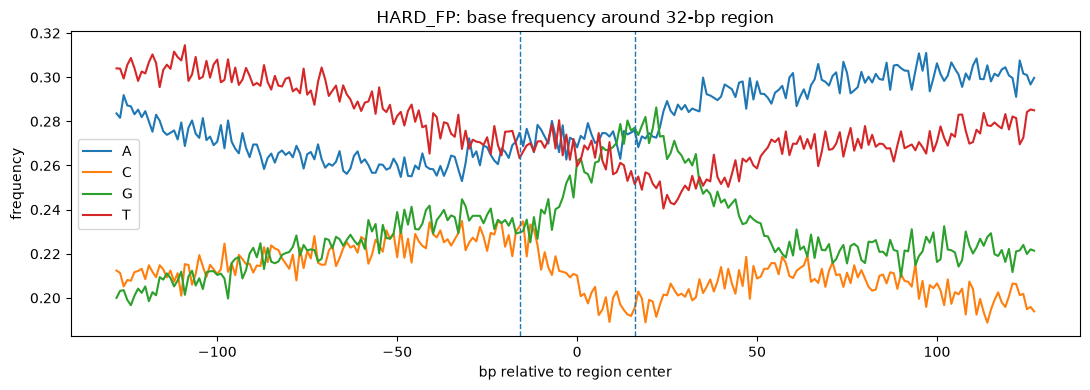

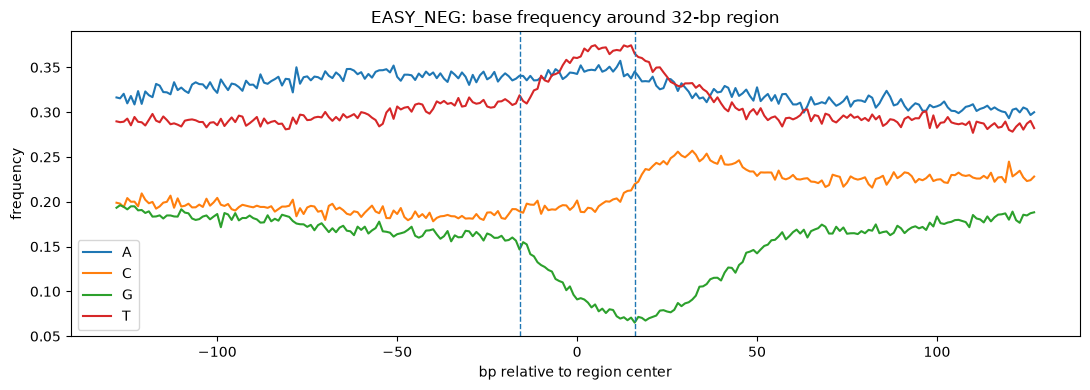

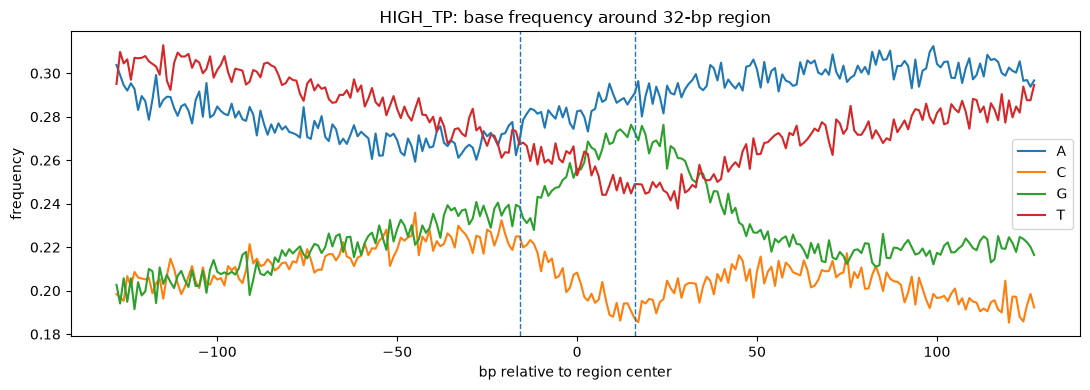

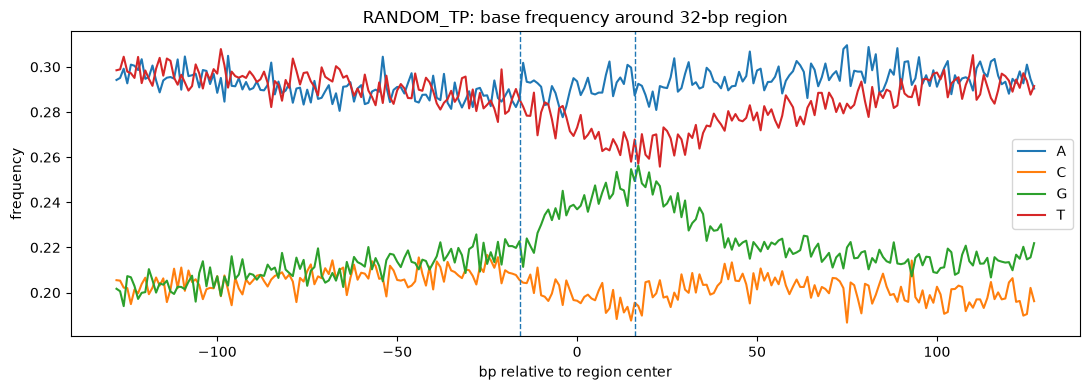

In [16]:
# ============================================================
# OPTIONAL POSITIONAL BASE-FREQUENCY DIAGNOSTIC
# ============================================================

import matplotlib.pyplot as plt


def base_frequency_matrix(
    seqs,
):
    matrix = np.zeros(
        (
            len(
                BASES
            ),
            CONTEXT_BP,
        ),
        dtype=np.float64,
    )

    for seq in seqs:
        for pos, char in enumerate(
            seq
        ):
            idx = np.flatnonzero(
                BASES
                == char
            )

            if idx.size:
                matrix[
                    int(
                        idx[0]
                    ),
                    pos,
                ] += 1.0

    matrix /= max(
        len(
            seqs
        ),
        1,
    )

    return matrix


relative_position = (
    np.arange(
        CONTEXT_BP
    )
    - HALF_CONTEXT
)

for group_name in (
    "HARD_FP",
    "EASY_NEG",
    "HIGH_TP",
    "RANDOM_TP",
):
    seqs = (
        selection.loc[
            selection[
                "group"
            ]
            == group_name,
            "seq_context256",
        ]
        .tolist()
    )

    matrix = (
        base_frequency_matrix(
            seqs
        )
    )

    plt.figure(
        figsize=(
            11,
            4,
        )
    )

    for base_index, base in enumerate(
        BASES[
            :4
        ]
    ):
        plt.plot(
            relative_position,
            matrix[
                base_index
            ],
            label=base,
        )

    plt.axvline(
        -16,
        linestyle="--",
        linewidth=1,
    )

    plt.axvline(
        16,
        linestyle="--",
        linewidth=1,
    )

    plt.title(
        f"{group_name}: base frequency around 32-bp region"
    )

    plt.xlabel(
        "bp relative to region center"
    )

    plt.ylabel(
        "frequency"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


In [17]:
# ============================================================
# SAVE RESULTS
# ============================================================

OUT_DIR = (
    EXP033_RUN_DIR
    / "false_positive_study"
)

OUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TOP_FP_PATH = (
    OUT_DIR
    / "top_10000_false_positives.csv"
)

GROUPS_PATH = (
    OUT_DIR
    / "diagnostic_sequence_groups.csv"
)

COMPOSITION_PATH = (
    OUT_DIR
    / "composition_summary.csv"
)

KMER_PATH = (
    OUT_DIR
    / "kmer6_enrichment.csv"
)

SIMILARITY_PATH = (
    OUT_DIR
    / "similarity_summary.csv"
)

SEPARABILITY_PATH = (
    OUT_DIR
    / "sequence_separability_auc.csv"
)

selection.loc[
    selection[
        "group"
    ]
    == "HARD_FP"
].sort_values(
    "score",
    ascending=False,
).to_csv(
    TOP_FP_PATH,
    index=False,
)

selection.to_csv(
    GROUPS_PATH,
    index=False,
)

composition_summary.to_csv(
    COMPOSITION_PATH,
    index=False,
)

kmer_enrichment.to_csv(
    KMER_PATH,
    index=False,
)

similarity_summary.to_csv(
    SIMILARITY_PATH,
    index=False,
)

separability.to_csv(
    SEPARABILITY_PATH,
    index=False,
)

print("Saved:", TOP_FP_PATH)
print("Saved:", GROUPS_PATH)
print("Saved:", COMPOSITION_PATH)
print("Saved:", KMER_PATH)
print("Saved:", SIMILARITY_PATH)
print("Saved:", SEPARABILITY_PATH)


Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\top_10000_false_positives.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\diagnostic_sequence_groups.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\composition_summary.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\kmer6_enrichment.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\similarity_summary.csv
Saved: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\sequence_separability_auc.csv


# Как интерпретировать результат

Сначала смотрим три вещи.

### 1. `HARD_FP vs HIGH_TP` — 4-mer Logistic Regression

```text
AUC ≈ 0.50–0.60
```

Очень сильный признак того, что на простом локальном sequence уровне FP и TP похожи.

```text
AUC ≫ 0.70
```

Значит между ними есть заметные sequence differences. Тогда нельзя говорить,
что мы упёрлись в biological state ceiling: вероятно, модель ещё не извлекает часть
доступного sequence signal.

### 2. Корреляция 6-mer enrichment

Сравниваем:

```text
HARD_FP vs EASY_NEG
HIGH_TP vs EASY_NEG
```

Если enrichment-профили сильно коррелируют и overlap top enriched k-mers высокий,
hard FPs действительно несут похожий локальный motif vocabulary.

### 3. Positive-centroid similarity

Если `HARD_FP` существенно ближе к `HIGH_TP` centroid, чем к `EASY_NEG`,
это ещё один независимый индикатор promoter-like sequence structure.

---

Даже если все три теста покажут очень сильное сходство FP с positives, вывод должен быть:

> «Есть свидетельства sequence-only ambiguity / experimental-state dependence».

А не:

> «CNN уже невозможно улучшить».

Остаются более длинный context, motif grammar, точная позиционная структура,
модель capacity и stochastic/experimental noise.


# Phase 2 — где находятся HARD_FP и что происходит после score matching

Теперь проверяем две гипотезы, возникшие после первого FP-анализа.

## A. HARD_FP просто находятся рядом с настоящими TSS?

Для `HARD_FP`, `EASY_NEG` и случайных negatives считаем расстояние до ближайшего:

- TSS на **том же strand**;
- TSS на **любом strand**;
- TSS на **противоположном strand**.

Пороговые окрестности:

```text
±32
±64
±128
±256
±512
±1024
±2048 bp
```

Это позволит увидеть, не являются ли HARD_FP просто соседними bins вокруг
настоящих initiation clusters.

## B. HARD_FP vs score-matched TP

Первый анализ имел circularity:

```text
HARD_FP = высокий score, target=0
HIGH_TP = высокий score, target=1
```

Поэтому здесь каждому HARD_FP подбирается **уникальный positive region с максимально
близким model score**.

После этого повторяем sequence-анализ:

- composition;
- 4-mer Logistic Regression;
- 6-mer enrichment similarity.

Если даже после score matching HARD_FP и positives почти неразличимы по локальной
последовательности, аргумент в пользу sequence-only ambiguity становится существенно сильнее.


In [18]:
# ============================================================
# SANITY CHECK — PHASE 1 OBJECTS MUST EXIST
# ============================================================

required_objects = (
    "selection",
    "scores_all",
    "targets_all",
    "tile_rows_all",
    "strands_all",
    "regions_all",
    "validation_tiles",
    "validation_generator",
    "group_index",
)

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run all Phase-1 cells first. Missing: "
        + ", ".join(
            missing_objects
        )
    )

assert REGION_WIDTH == 32
assert TARGET_LENGTH == 2048

print(
    "Phase-1 objects: OK"
)


Phase-1 objects: OK


In [19]:
# ============================================================
# DETECT GENOMIC TARGET COORDINATE COLUMN
# ============================================================
# We intentionally refuse to guess from a generic `start` column.
# A wrong coordinate origin would silently corrupt all distance results.

TARGET_START_COLUMN = None

for candidate in (
    "target_start_0based",
    "target_start",
):
    if candidate in validation_tiles.columns:
        TARGET_START_COLUMN = (
            candidate
        )
        break

if TARGET_START_COLUMN is None:
    print(
        "validation_tiles columns:"
    )

    print(
        list(
            validation_tiles.columns
        )
    )

    raise RuntimeError(
        "No explicit target_start column found. "
        "Set TARGET_START_COLUMN manually after inspecting the columns."
    )

if "contig" not in validation_tiles.columns:
    raise RuntimeError(
        "validation_tiles must contain a contig column."
    )

print(
    "Target coordinate column:",
    TARGET_START_COLUMN,
)

display(
    validation_tiles[
        [
            "contig",
            TARGET_START_COLUMN,
        ]
    ].head()
)


Target coordinate column: target_start


,contig,target_start
0,NC_064034.1,0
1,NC_064034.1,2048
2,NC_064034.1,4096
3,NC_064034.1,6144
4,NC_064034.1,8192


In [20]:
# ============================================================
# BUILD EXACT HOLDOUT TSS CATALOG
# ============================================================
# Exact base positions, not 32-bp regional labels.
# Key: (contig, strand_index) -> sorted unique genomic positions.

from collections import defaultdict

TSS_BATCH_SIZE = 32

tss_parts = defaultdict(
    list
)

started = time.perf_counter()

for batch_no, start in enumerate(
    range(
        0,
        len(validation_tiles),
        TSS_BATCH_SIZE,
    ),
    1,
):
    selected_tiles = (
        validation_tiles
        .iloc[
            start:
            start
            + TSS_BATCH_SIZE
        ]
    )

    batch = (
        validation_generator
        .make_batch(
            selected_tiles
        )
    )

    counts = (
        batch.count
        .numpy()
    )

    mask = (
        batch.mask
        .numpy()
        .astype(bool)
    )

    B = len(
        selected_tiles
    )

    for local in range(B):
        tile_row = (
            start
            + local
        )

        contig = str(
            validation_tiles
            .iloc[
                tile_row
            ][
                "contig"
            ]
        )

        target_start = int(
            validation_tiles
            .iloc[
                tile_row
            ][
                TARGET_START_COLUMN
            ]
        )

        for strand_index in (
            0,
            1,
        ):
            positive_local = np.flatnonzero(
                (
                    counts[
                        local,
                        strand_index,
                    ]
                    > 0
                )
                & mask[
                    local,
                    strand_index,
                ]
            )

            if positive_local.size:
                tss_parts[
                    (
                        contig,
                        strand_index,
                    )
                ].append(
                    target_start
                    + positive_local
                )

    done = min(
        start
        + B,
        len(validation_tiles),
    )

    if (
        batch_no == 1
        or batch_no % 250 == 0
        or done
        == len(validation_tiles)
    ):
        print(
            f"tiles scanned="
            f"{done:,}/"
            f"{len(validation_tiles):,}"
        )


tss_catalog = {}

for key, pieces in (
    tss_parts.items()
):
    tss_catalog[
        key
    ] = np.unique(
        np.concatenate(
            pieces
        ).astype(
            np.int64
        )
    )

catalog_total = sum(
    len(x)
    for x in (
        tss_catalog.values()
    )
)

print()
print(
    "Unique exact strand-specific TSS positions:",
    f"{catalog_total:,}",
)

print(
    "Elapsed min:",
    round(
        (
            time.perf_counter()
            - started
        )
        / 60.0,
        2,
    ),
)


tiles scanned=32/24,700
tiles scanned=8,000/24,700
tiles scanned=16,000/24,700
tiles scanned=24,000/24,700
tiles scanned=24,700/24,700

Unique exact strand-specific TSS positions: 56,205
Elapsed min: 0.1


In [21]:
# ============================================================
# HELPERS: CATALOG INDEX -> GENOMIC REGION
# ============================================================

tile_target_starts = (
    validation_tiles[
        TARGET_START_COLUMN
    ]
    .to_numpy(
        dtype=np.int64
    )
)

tile_contigs = (
    validation_tiles[
        "contig"
    ]
    .astype(str)
    .to_numpy()
)


def catalog_region_metadata(
    catalog_indices,
):
    catalog_indices = np.asarray(
        catalog_indices,
        dtype=np.int64,
    )

    tile_rows = (
        tile_rows_all[
            catalog_indices
        ]
    )

    strand_indices = (
        strands_all[
            catalog_indices
        ]
    )

    region_indices = (
        regions_all[
            catalog_indices
        ]
    )

    starts = (
        tile_target_starts[
            tile_rows
        ]
        + region_indices.astype(
            np.int64
        )
        * REGION_WIDTH
    )

    ends = (
        starts
        + REGION_WIDTH
    )

    centers = (
        starts
        + REGION_WIDTH // 2
    )

    contigs = (
        tile_contigs[
            tile_rows
        ]
    )

    return pd.DataFrame({
        "catalog_index": (
            catalog_indices
        ),
        "score": (
            scores_all[
                catalog_indices
            ]
        ),
        "target": (
            targets_all[
                catalog_indices
            ]
        ),
        "tile_row": (
            tile_rows
        ),
        "strand_index": (
            strand_indices
        ),
        "strand": np.where(
            strand_indices == 0,
            "+",
            "-",
        ),
        "region_index": (
            region_indices
        ),
        "contig": (
            contigs
        ),
        "region_start_0based": (
            starts
        ),
        "region_end_0based": (
            ends
        ),
        "region_center_0based": (
            centers
        ),
    })


def nearest_coord(
    sorted_coords,
    position,
):
    if (
        sorted_coords is None
        or len(sorted_coords) == 0
    ):
        return None

    i = int(
        np.searchsorted(
            sorted_coords,
            position,
            side="left",
        )
    )

    candidates = []

    if i > 0:
        candidates.append(
            int(
                sorted_coords[
                    i - 1
                ]
            )
        )

    if i < len(
        sorted_coords
    ):
        candidates.append(
            int(
                sorted_coords[
                    i
                ]
            )
        )

    if not candidates:
        return None

    return min(
        candidates,
        key=lambda x: abs(
            x - position
        ),
    )


def annotate_nearest_tss(
    frame,
):
    frame = (
        frame.copy()
        .reset_index(
            drop=True
        )
    )

    same_dist = np.full(
        len(frame),
        np.nan,
        dtype=np.float64,
    )

    any_dist = np.full(
        len(frame),
        np.nan,
        dtype=np.float64,
    )

    opposite_dist = np.full(
        len(frame),
        np.nan,
        dtype=np.float64,
    )

    oriented_signed_same = np.full(
        len(frame),
        np.nan,
        dtype=np.float64,
    )

    nearest_same_coord = np.full(
        len(frame),
        -1,
        dtype=np.int64,
    )

    for i, row in frame.iterrows():
        contig = str(
            row[
                "contig"
            ]
        )

        strand = int(
            row[
                "strand_index"
            ]
        )

        center = int(
            row[
                "region_center_0based"
            ]
        )

        same_coords = (
            tss_catalog.get(
                (
                    contig,
                    strand,
                )
            )
        )

        opposite_coords = (
            tss_catalog.get(
                (
                    contig,
                    1 - strand,
                )
            )
        )

        same = nearest_coord(
            same_coords,
            center,
        )

        opposite = nearest_coord(
            opposite_coords,
            center,
        )

        if same is not None:
            delta = (
                int(
                    same
                )
                - center
            )

            same_dist[
                i
            ] = abs(
                delta
            )

            # Oriented coordinate:
            # positive = downstream on the predicted strand.
            oriented_signed_same[
                i
            ] = (
                delta
                if strand == 0
                else -delta
            )

            nearest_same_coord[
                i
            ] = int(
                same
            )

        if opposite is not None:
            opposite_dist[
                i
            ] = abs(
                int(
                    opposite
                )
                - center
            )

        finite_candidates = [
            x
            for x in (
                same_dist[
                    i
                ],
                opposite_dist[
                    i
                ],
            )
            if np.isfinite(
                x
            )
        ]

        if finite_candidates:
            any_dist[
                i
            ] = min(
                finite_candidates
            )

    frame[
        "nearest_same_strand_tss_distance_bp"
    ] = same_dist

    frame[
        "nearest_any_strand_tss_distance_bp"
    ] = any_dist

    frame[
        "nearest_opposite_strand_tss_distance_bp"
    ] = opposite_dist

    frame[
        "nearest_same_strand_tss_signed_oriented_bp"
    ] = oriented_signed_same

    frame[
        "nearest_same_strand_tss_coord_0based"
    ] = nearest_same_coord

    return frame


In [22]:
# ============================================================
# DISTANCE COHORTS
# ============================================================

DISTANCE_GROUP_N = 10_000

hard_fp_idx = (
    group_index[
        "HARD_FP"
    ]
)

easy_neg_idx = (
    group_index[
        "EASY_NEG"
    ]
)

negative_idx = np.flatnonzero(
    ~targets_all
)

excluded_negative = np.concatenate(
    (
        hard_fp_idx,
        easy_neg_idx,
    )
)

random_negative_pool = np.setdiff1d(
    negative_idx,
    excluded_negative,
    assume_unique=False,
)

random_neg_idx = RNG.choice(
    random_negative_pool,
    size=DISTANCE_GROUP_N,
    replace=False,
)

distance_frames = []

for group_name, idx in (
    (
        "HARD_FP",
        hard_fp_idx,
    ),
    (
        "EASY_NEG",
        easy_neg_idx,
    ),
    (
        "RANDOM_NEG",
        random_neg_idx,
    ),
):
    frame = (
        catalog_region_metadata(
            idx
        )
    )

    frame.insert(
        0,
        "group",
        group_name,
    )

    frame = (
        annotate_nearest_tss(
            frame
        )
    )

    distance_frames.append(
        frame
    )

distance_regions = pd.concat(
    distance_frames,
    ignore_index=True,
)

distance_summary = (
    distance_regions
    .groupby(
        "group",
        as_index=False,
    )
    .agg(
        n=(
            "score",
            "size",
        ),
        score_median=(
            "score",
            "median",
        ),
        same_strand_tss_distance_median=(
            "nearest_same_strand_tss_distance_bp",
            "median",
        ),
        any_strand_tss_distance_median=(
            "nearest_any_strand_tss_distance_bp",
            "median",
        ),
        opposite_strand_tss_distance_median=(
            "nearest_opposite_strand_tss_distance_bp",
            "median",
        ),
    )
)

display(
    distance_summary
)


,group,n,score_median,same_strand_tss_distance_median,any_strand_tss_distance_median,opposite_strand_tss_distance_median
0,EASY_NEG,10000,0.002790,4695.0,1528.5,2416.5
1,HARD_FP,10000,0.981931,1856.0,971.5,4791.0
2,RANDOM_NEG,10000,0.193089,3194.0,1289.0,3128.0


In [23]:
# ============================================================
# CUMULATIVE FRACTION NEAR A TRUE TSS
# ============================================================

DISTANCE_THRESHOLDS = (
    32,
    64,
    128,
    256,
    512,
    1024,
    2048,
)

distance_columns = {
    "same_strand": (
        "nearest_same_strand_tss_distance_bp"
    ),
    "any_strand": (
        "nearest_any_strand_tss_distance_bp"
    ),
    "opposite_strand": (
        "nearest_opposite_strand_tss_distance_bp"
    ),
}

rows = []

for group_name, frame in (
    distance_regions
    .groupby(
        "group"
    )
):
    for distance_type, column in (
        distance_columns.items()
    ):
        values = (
            frame[
                column
            ]
            .to_numpy(
                dtype=np.float64
            )
        )

        finite = np.isfinite(
            values
        )

        for threshold in (
            DISTANCE_THRESHOLDS
        ):
            rows.append({
                "group": (
                    group_name
                ),
                "distance_type": (
                    distance_type
                ),
                "threshold_bp": (
                    threshold
                ),
                "fraction_within_threshold": float(
                    np.mean(
                        finite
                        & (
                            values
                            <= threshold
                        )
                    )
                ),
            })

distance_cumulative = (
    pd.DataFrame(
        rows
    )
)

print(
    "=== SAME-STRAND TSS ==="
)

display(
    distance_cumulative[
        distance_cumulative[
            "distance_type"
        ]
        == "same_strand"
    ].pivot(
        index="threshold_bp",
        columns="group",
        values="fraction_within_threshold",
    )
)

print()
print(
    "=== ANY-STRAND TSS ==="
)

display(
    distance_cumulative[
        distance_cumulative[
            "distance_type"
        ]
        == "any_strand"
    ].pivot(
        index="threshold_bp",
        columns="group",
        values="fraction_within_threshold",
    )
)

print()
print(
    "=== OPPOSITE-STRAND TSS ==="
)

display(
    distance_cumulative[
        distance_cumulative[
            "distance_type"
        ]
        == "opposite_strand"
    ].pivot(
        index="threshold_bp",
        columns="group",
        values="fraction_within_threshold",
    )
)


=== SAME-STRAND TSS ===


group,EASY_NEG,HARD_FP,RANDOM_NEG
threshold_bp,,,
32,0.0001,0.0917,0.0083
64,0.0016,0.1669,0.0224
128,0.0073,0.2229,0.0460
256,0.0281,0.2740,0.0868
512,0.0705,0.3301,0.1587
1024,0.1499,0.4106,0.2662
2048,0.2841,0.5176,0.3967



=== ANY-STRAND TSS ===


group,EASY_NEG,HARD_FP,RANDOM_NEG
threshold_bp,,,
32,0.0044,0.1023,0.0282
64,0.0116,0.1853,0.0542
128,0.0374,0.2543,0.1005
256,0.1096,0.3255,0.1733
512,0.2255,0.4011,0.2871
1024,0.3918,0.5094,0.4435
2048,0.5874,0.6414,0.6162



=== OPPOSITE-STRAND TSS ===


group,EASY_NEG,HARD_FP,RANDOM_NEG
threshold_bp,,,
32,0.0043,0.0125,0.0199
64,0.0100,0.0248,0.0322
128,0.0302,0.0528,0.0583
256,0.0832,0.0946,0.0995
512,0.1675,0.1540,0.1644
1024,0.2886,0.2257,0.2669
2048,0.4504,0.3245,0.4022


In [24]:
# ============================================================
# ORIENTED DIRECTION OF THE NEAREST SAME-STRAND TSS
# ============================================================

orientation_rows = []

for group_name, frame in (
    distance_regions
    .groupby(
        "group"
    )
):
    delta = (
        frame[
            "nearest_same_strand_tss_signed_oriented_bp"
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    finite = np.isfinite(
        delta
    )

    close = (
        finite
        & (
            np.abs(
                delta
            )
            <= 1024
        )
    )

    close_values = (
        delta[
            close
        ]
    )

    orientation_rows.append({
        "group": group_name,
        "n_with_same_strand_tss_within_1kb": int(
            close.sum()
        ),
        "fraction_upstream_among_close": (
            float(
                np.mean(
                    close_values < 0
                )
            )
            if close_values.size
            else np.nan
        ),
        "fraction_downstream_among_close": (
            float(
                np.mean(
                    close_values > 0
                )
            )
            if close_values.size
            else np.nan
        ),
        "signed_distance_median_bp": (
            float(
                np.median(
                    close_values
                )
            )
            if close_values.size
            else np.nan
        ),
    })

orientation_summary = (
    pd.DataFrame(
        orientation_rows
    )
)

display(
    orientation_summary
)


,group,n_with_same_strand_tss_within_1kb,fraction_upstream_among_close,fraction_downstream_among_close,signed_distance_median_bp
0,EASY_NEG,1499,0.423616,0.576384,209.0
1,HARD_FP,4106,0.496347,0.503653,16.0
2,RANDOM_NEG,2662,0.485725,0.514275,30.0


## Score matching

Ниже используется one-to-one matching **без повторного использования positive region**.

Алгоритм простой и прозрачный:

1. сортируем все positive regions по score;
2. идём по HARD_FP от самого высокого score вниз;
3. каждому HARD_FP назначаем ближайший ещё не использованный positive score.

Это не идеальный causal matching — здесь такой цели нет. Нам нужен диагностический контроль,
чтобы убрать большую часть различия, обусловленного самим фактом отбора по score.


In [25]:
# ============================================================
# UNIQUE GREEDY SCORE MATCHING: HARD_FP -> POSITIVE REGION
# ============================================================

positive_idx = np.flatnonzero(
    targets_all
)

positive_scores = (
    scores_all[
        positive_idx
    ]
)

positive_sort_order = np.argsort(
    positive_scores,
    kind="mergesort",
)

positive_idx_sorted = (
    positive_idx[
        positive_sort_order
    ]
)

positive_scores_sorted = (
    positive_scores[
        positive_sort_order
    ]
)

hard_fp_order = np.argsort(
    -scores_all[
        hard_fp_idx
    ],
    kind="mergesort",
)

hard_fp_sorted = (
    hard_fp_idx[
        hard_fp_order
    ]
)

used = np.zeros(
    len(
        positive_idx_sorted
    ),
    dtype=bool,
)

matched_positive_sorted = np.empty(
    len(
        hard_fp_sorted
    ),
    dtype=np.int64,
)

matched_diff_sorted = np.empty(
    len(
        hard_fp_sorted
    ),
    dtype=np.float64,
)


for out_i, fp_catalog_idx in enumerate(
    hard_fp_sorted
):
    target_score = float(
        scores_all[
            fp_catalog_idx
        ]
    )

    insertion = int(
        np.searchsorted(
            positive_scores_sorted,
            target_score,
            side="left",
        )
    )

    left = (
        insertion - 1
    )

    right = (
        insertion
    )

    while True:
        while (
            left >= 0
            and used[
                left
            ]
        ):
            left -= 1

        while (
            right
            < len(
                used
            )
            and used[
                right
            ]
        ):
            right += 1

        left_diff = (
            abs(
                float(
                    positive_scores_sorted[
                        left
                    ]
                )
                - target_score
            )
            if left >= 0
            else np.inf
        )

        right_diff = (
            abs(
                float(
                    positive_scores_sorted[
                        right
                    ]
                )
                - target_score
            )
            if right
            < len(
                used
            )
            else np.inf
        )

        if not np.isfinite(
            min(
                left_diff,
                right_diff,
            )
        ):
            raise RuntimeError(
                "Ran out of unmatched positive regions."
            )

        if left_diff <= right_diff:
            chosen = (
                left
            )
        else:
            chosen = (
                right
            )

        used[
            chosen
        ] = True

        matched_positive_sorted[
            out_i
        ] = (
            positive_idx_sorted[
                chosen
            ]
        )

        matched_diff_sorted[
            out_i
        ] = abs(
            float(
                positive_scores_sorted[
                    chosen
                ]
            )
            - target_score
        )

        break


# Restore HARD_FP original group order.
inverse_hard_order = np.empty_like(
    hard_fp_order
)

inverse_hard_order[
    hard_fp_order
] = np.arange(
    len(
        hard_fp_order
    )
)

matched_positive_idx = (
    matched_positive_sorted[
        inverse_hard_order
    ]
)

matched_score_diff = (
    matched_diff_sorted[
        inverse_hard_order
    ]
)

assert len(
    np.unique(
        matched_positive_idx
    )
) == len(
    matched_positive_idx
)

assert np.all(
    targets_all[
        matched_positive_idx
    ]
)

matching_summary = pd.DataFrame({
    "metric": (
        "abs_score_difference"
    ),
    "quantile": (
        0.00,
        0.50,
        0.90,
        0.95,
        0.99,
        1.00,
    ),
    "value": [
        float(
            np.quantile(
                matched_score_diff,
                q,
            )
        )
        for q in (
            0.00,
            0.50,
            0.90,
            0.95,
            0.99,
            1.00,
        )
    ],
})

display(
    matching_summary
)

print(
    "HARD_FP median score:",
    float(
        np.median(
            scores_all[
                hard_fp_idx
            ]
        )
    ),
)

print(
    "Matched TP median score:",
    float(
        np.median(
            scores_all[
                matched_positive_idx
            ]
        )
    ),
)


,metric,quantile,value
0,abs_score_difference,0.00,1.788139e-07
1,abs_score_difference,0.50,2.751768e-02
2,abs_score_difference,0.90,6.937260e-02
3,abs_score_difference,0.95,7.564997e-02
4,abs_score_difference,0.99,8.079578e-02
5,abs_score_difference,1.00,8.200347e-02


HARD_FP median score: 0.981931209564209
Matched TP median score: 0.9544135332107544


In [26]:
# ============================================================
# EXTRACT 256-BP STRAND-ORIENTED SEQUENCES FOR MATCHED TP
# ============================================================

def extract_sequences_for_catalog_indices(
    catalog_indices,
):
    frame = (
        catalog_region_metadata(
            catalog_indices
        )
        .reset_index(
            drop=True
        )
    )

    frame[
        "seq_core32"
    ] = ""

    frame[
        "seq_context256"
    ] = ""

    frame_groups = (
        frame
        .groupby(
            "tile_row"
        )
        .indices
    )

    unique_tile_rows = np.array(
        sorted(
            frame_groups.keys()
        ),
        dtype=np.int64,
    )

    extract_batch_size = 64

    for batch_start in range(
        0,
        len(
            unique_tile_rows
        ),
        extract_batch_size,
    ):
        tile_rows = (
            unique_tile_rows[
                batch_start:
                batch_start
                + extract_batch_size
            ]
        )

        batch = (
            validation_generator
            .make_batch(
                validation_tiles
                .iloc[
                    tile_rows
                ]
            )
        )

        x = (
            batch
            .x_both_strands
            .numpy()
        )

        B = len(
            tile_rows
        )

        tile_to_local = {
            int(tile_row): local
            for local, tile_row
            in enumerate(
                tile_rows
            )
        }

        for tile_row in tile_rows:
            local = (
                tile_to_local[
                    int(
                        tile_row
                    )
                ]
            )

            for frame_row in (
                frame_groups[
                    int(
                        tile_row
                    )
                ]
            ):
                strand_index = int(
                    frame.at[
                        frame_row,
                        "strand_index",
                    ]
                )

                genomic_region = int(
                    frame.at[
                        frame_row,
                        "region_index",
                    ]
                )

                if strand_index == 0:
                    oriented_row = (
                        local
                    )

                    oriented_region = (
                        genomic_region
                    )

                else:
                    oriented_row = (
                        B + local
                    )

                    oriented_region = (
                        N_REGIONS
                        - 1
                        - genomic_region
                    )

                core_start = (
                    CONTEXT_FLANK
                    + oriented_region
                    * REGION_WIDTH
                )

                core_end = (
                    core_start
                    + REGION_WIDTH
                )

                center = (
                    core_start
                    + REGION_WIDTH // 2
                )

                context_start = (
                    center
                    - HALF_CONTEXT
                )

                context_end = (
                    center
                    + HALF_CONTEXT
                )

                core_codes = np.argmax(
                    x[
                        oriented_row,
                        :,
                        core_start:
                        core_end,
                    ],
                    axis=0,
                )

                context_codes = np.argmax(
                    x[
                        oriented_row,
                        :,
                        context_start:
                        context_end,
                    ],
                    axis=0,
                )

                frame.at[
                    frame_row,
                    "seq_core32",
                ] = "".join(
                    BASES[
                        core_codes
                    ]
                )

                frame.at[
                    frame_row,
                    "seq_context256",
                ] = "".join(
                    BASES[
                        context_codes
                    ]
                )

    assert (
        frame[
            "seq_core32"
        ]
        .str.len()
        .eq(
            REGION_WIDTH
        )
        .all()
    )

    assert (
        frame[
            "seq_context256"
        ]
        .str.len()
        .eq(
            CONTEXT_BP
        )
        .all()
    )

    return frame


score_matched_tp = (
    extract_sequences_for_catalog_indices(
        matched_positive_idx
    )
)

score_matched_tp.insert(
    0,
    "group",
    "SCORE_MATCHED_TP",
)

score_matched_tp[
    "matched_hard_fp_catalog_index"
] = (
    hard_fp_idx
)

score_matched_tp[
    "abs_score_difference"
] = (
    matched_score_diff
)

display(
    score_matched_tp[
        [
            "score",
            "abs_score_difference",
            "contig",
            "strand",
            "region_start_0based",
        ]
    ].head()
)


,score,abs_score_difference,contig,strand,region_start_0based
0,0.999933,0.000022,NC_064042.1,-,2729600
1,0.999924,0.000012,NC_064041.1,+,13057632
2,0.999893,0.000011,NC_064042.1,-,1218912
3,0.999809,0.000002,NC_064042.1,+,5478560
4,0.999644,0.000012,NC_064042.1,-,9527040


In [27]:
# ============================================================
# COMPOSITION: HARD_FP vs SCORE_MATCHED_TP
# ============================================================

hard_fp_sequences = (
    selection.loc[
        selection[
            "group"
        ]
        == "HARD_FP"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

matched_core_stats = np.array(
    [
        sequence_stats(
            seq
        )
        for seq in (
            score_matched_tp[
                "seq_core32"
            ]
        )
    ],
    dtype=np.float64,
)

matched_context_stats = np.array(
    [
        sequence_stats(
            seq
        )
        for seq in (
            score_matched_tp[
                "seq_context256"
            ]
        )
    ],
    dtype=np.float64,
)

score_matched_tp[
    "gc_core32"
] = (
    matched_core_stats[
        :,
        0,
    ]
)

score_matched_tp[
    "n_fraction_core32"
] = (
    matched_core_stats[
        :,
        1,
    ]
)

score_matched_tp[
    "entropy_core32"
] = (
    matched_core_stats[
        :,
        2,
    ]
)

score_matched_tp[
    "gc_context256"
] = (
    matched_context_stats[
        :,
        0,
    ]
)

score_matched_tp[
    "n_fraction_context256"
] = (
    matched_context_stats[
        :,
        1,
    ]
)

score_matched_tp[
    "entropy_context256"
] = (
    matched_context_stats[
        :,
        2,
    ]
)

matched_composition = pd.DataFrame([
    {
        "group": "HARD_FP",
        "score_median": float(
            hard_fp_sequences[
                "score"
            ].median()
        ),
        "gc_core32_mean": float(
            hard_fp_sequences[
                "gc_core32"
            ].mean()
        ),
        "gc_context256_mean": float(
            hard_fp_sequences[
                "gc_context256"
            ].mean()
        ),
        "entropy_core32_mean": float(
            hard_fp_sequences[
                "entropy_core32"
            ].mean()
        ),
        "entropy_context256_mean": float(
            hard_fp_sequences[
                "entropy_context256"
            ].mean()
        ),
    },
    {
        "group": "SCORE_MATCHED_TP",
        "score_median": float(
            score_matched_tp[
                "score"
            ].median()
        ),
        "gc_core32_mean": float(
            score_matched_tp[
                "gc_core32"
            ].mean()
        ),
        "gc_context256_mean": float(
            score_matched_tp[
                "gc_context256"
            ].mean()
        ),
        "entropy_core32_mean": float(
            score_matched_tp[
                "entropy_core32"
            ].mean()
        ),
        "entropy_context256_mean": float(
            score_matched_tp[
                "entropy_context256"
            ].mean()
        ),
    },
])

display(
    matched_composition
)


,group,score_median,gc_core32_mean,gc_context256_mean,entropy_core32_mean,entropy_context256_mean
0,HARD_FP,0.981931,0.461137,0.442487,1.903761,1.970455
1,SCORE_MATCHED_TP,0.954414,0.459688,0.435557,1.904421,1.968115


In [28]:
# ============================================================
# SCORE-MATCHED 4-MER LOGISTIC REGRESSION
# ============================================================
# Pair-level split: each matched pair goes wholly to train or test.

X_hard = np.stack(
    [
        kmer_vector(
            seq
        )
        for seq in (
            hard_fp_sequences[
                "seq_context256"
            ]
        )
    ]
)

X_matched = np.stack(
    [
        kmer_vector(
            seq
        )
        for seq in (
            score_matched_tp[
                "seq_context256"
            ]
        )
    ]
)

assert (
    X_hard.shape
    == X_matched.shape
)

n_pairs = (
    X_hard.shape[0]
)

pair_indices = np.arange(
    n_pairs
)

pair_train, pair_test = (
    train_test_split(
        pair_indices,
        test_size=0.30,
        random_state=42,
    )
)


def make_pair_dataset(
    pair_ids,
):
    X = np.concatenate(
        (
            X_hard[
                pair_ids
            ],
            X_matched[
                pair_ids
            ],
        ),
        axis=0,
    )

    y = np.concatenate(
        (
            np.ones(
                len(
                    pair_ids
                ),
                dtype=np.int8,
            ),
            np.zeros(
                len(
                    pair_ids
                ),
                dtype=np.int8,
            ),
        )
    )

    return (
        X,
        y,
    )


X_train, y_train = (
    make_pair_dataset(
        pair_train
    )
)

X_test, y_test = (
    make_pair_dataset(
        pair_test
    )
)

matched_clf = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="liblinear",
    random_state=42,
)

matched_clf.fit(
    X_train,
    y_train,
)

matched_probability = (
    matched_clf
    .predict_proba(
        X_test
    )[
        :,
        1,
    ]
)

matched_auc = float(
    roc_auc_score(
        y_test,
        matched_probability,
    )
)

print(
    "HARD_FP vs SCORE_MATCHED_TP "
    "4-mer Logistic Regression AUC:",
    round(
        matched_auc,
        6,
    ),
)

print(
    "Pairs train/test:",
    len(
        pair_train
    ),
    "/",
    len(
        pair_test
    ),
)


HARD_FP vs SCORE_MATCHED_TP 4-mer Logistic Regression AUC: 0.606012
Pairs train/test: 7000 / 3000


In [29]:
# ============================================================
# SCORE-MATCHED 6-MER ENRICHMENT
# ============================================================

easy_neg_sequences = (
    selection.loc[
        selection[
            "group"
        ]
        == "EASY_NEG",
        "seq_context256",
    ]
    .tolist()
)

hard_counter, hard_total = (
    aggregate_kmers(
        hard_fp_sequences[
            "seq_context256"
        ],
        K,
    )
)

matched_counter, matched_total = (
    aggregate_kmers(
        score_matched_tp[
            "seq_context256"
        ],
        K,
    )
)

easy_counter, easy_total = (
    aggregate_kmers(
        easy_neg_sequences,
        K,
    )
)

all_matched_kmers = sorted(
    set(
        hard_counter
    )
    | set(
        matched_counter
    )
    | set(
        easy_counter
    )
)

matched_kmer_rows = []

for kmer in all_matched_kmers:
    hard_freq = (
        hard_counter[
            kmer
        ]
        + PSEUDOCOUNT
    ) / (
        hard_total
        + PSEUDOCOUNT
        * vocab_size
    )

    matched_freq = (
        matched_counter[
            kmer
        ]
        + PSEUDOCOUNT
    ) / (
        matched_total
        + PSEUDOCOUNT
        * vocab_size
    )

    easy_freq = (
        easy_counter[
            kmer
        ]
        + PSEUDOCOUNT
    ) / (
        easy_total
        + PSEUDOCOUNT
        * vocab_size
    )

    matched_kmer_rows.append({
        "kmer": kmer,
        "log2_HARD_FP_vs_EASY_NEG": (
            np.log2(
                hard_freq
                / easy_freq
            )
        ),
        "log2_MATCHED_TP_vs_EASY_NEG": (
            np.log2(
                matched_freq
                / easy_freq
            )
        ),
        "log2_HARD_FP_vs_MATCHED_TP": (
            np.log2(
                hard_freq
                / matched_freq
            )
        ),
    })

matched_kmer_enrichment = (
    pd.DataFrame(
        matched_kmer_rows
    )
)

matched_enrichment_corr = float(
    np.corrcoef(
        matched_kmer_enrichment[
            "log2_HARD_FP_vs_EASY_NEG"
        ],
        matched_kmer_enrichment[
            "log2_MATCHED_TP_vs_EASY_NEG"
        ],
    )[
        0,
        1,
    ]
)

top_n = 50

matched_top_fp = set(
    matched_kmer_enrichment
    .nlargest(
        top_n,
        "log2_HARD_FP_vs_EASY_NEG",
    )[
        "kmer"
    ]
)

matched_top_tp = set(
    matched_kmer_enrichment
    .nlargest(
        top_n,
        "log2_MATCHED_TP_vs_EASY_NEG",
    )[
        "kmer"
    ]
)

matched_top50_jaccard = (
    len(
        matched_top_fp
        & matched_top_tp
    )
    / len(
        matched_top_fp
        | matched_top_tp
    )
)

matched_abs_log2_ratio_median = float(
    np.median(
        np.abs(
            matched_kmer_enrichment[
                "log2_HARD_FP_vs_MATCHED_TP"
            ]
        )
    )
)

print(
    "6-mer enrichment correlation "
    "(HARD_FP vs easy, MATCHED_TP vs easy):",
    round(
        matched_enrichment_corr,
        4,
    ),
)

print(
    "Jaccard overlap of top-50 enriched 6-mers:",
    round(
        matched_top50_jaccard,
        4,
    ),
)

print(
    "Median |log2(HARD_FP / MATCHED_TP)| across 6-mers:",
    round(
        matched_abs_log2_ratio_median,
        4,
    ),
)

print()
print(
    "=== LARGEST DIRECT 6-MER DIFFERENCES ==="
)

display(
    matched_kmer_enrichment
    .assign(
        abs_log2_diff=lambda df: np.abs(
            df[
                "log2_HARD_FP_vs_MATCHED_TP"
            ]
        )
    )
    .nlargest(
        30,
        "abs_log2_diff",
    )[
        [
            "kmer",
            "log2_HARD_FP_vs_MATCHED_TP",
            "log2_HARD_FP_vs_EASY_NEG",
            "log2_MATCHED_TP_vs_EASY_NEG",
        ]
    ]
)


6-mer enrichment correlation (HARD_FP vs easy, MATCHED_TP vs easy): 0.9814
Jaccard overlap of top-50 enriched 6-mers: 0.4286
Median |log2(HARD_FP / MATCHED_TP)| across 6-mers: 0.1164

=== LARGEST DIRECT 6-MER DIFFERENCES ===


,kmer,log2_HARD_FP_vs_MATCHED_TP,log2_HARD_FP_vs_EASY_NEG,log2_MATCHED_TP_vs_EASY_NEG
2298,GATTGG,1.082075,2.317492,1.235417
2645,GGCCCC,1.013872,0.552444,-0.461428
1638,CGCGCG,0.913929,2.274518,1.360589
3646,TGATTG,0.872635,2.007469,1.134833
1001,ATTGGC,0.835632,1.572508,0.736876
1317,CCAGCC,0.820147,0.558556,-0.261592
2918,GTCGCG,0.753443,2.870265,2.116822
2390,GCCCCG,0.735267,0.826607,0.091340
2377,GCCAGC,0.706804,1.337224,0.630420
1293,CCAATC,0.695975,1.122282,0.426306


In [30]:
# ============================================================
# SAVE PHASE-2 RESULTS
# ============================================================

PHASE2_DIR = (
    EXP033_RUN_DIR
    / "false_positive_study"
    / "phase2_nearest_tss_score_matching"
)

PHASE2_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

distance_regions.to_csv(
    PHASE2_DIR
    / "negative_groups_nearest_tss.csv",
    index=False,
)

distance_summary.to_csv(
    PHASE2_DIR
    / "nearest_tss_summary.csv",
    index=False,
)

distance_cumulative.to_csv(
    PHASE2_DIR
    / "nearest_tss_cumulative_thresholds.csv",
    index=False,
)

orientation_summary.to_csv(
    PHASE2_DIR
    / "nearest_tss_oriented_direction.csv",
    index=False,
)

score_matched_tp.to_csv(
    PHASE2_DIR
    / "score_matched_true_positives.csv",
    index=False,
)

matching_summary.to_csv(
    PHASE2_DIR
    / "score_matching_quality.csv",
    index=False,
)

matched_composition.to_csv(
    PHASE2_DIR
    / "score_matched_composition.csv",
    index=False,
)

pd.DataFrame(
    [
        {
            "comparison": (
                "HARD_FP vs SCORE_MATCHED_TP"
            ),
            "roc_auc_4mer_logreg": (
                matched_auc
            ),
            "pair_split": True,
        }
    ]
).to_csv(
    PHASE2_DIR
    / "score_matched_4mer_logreg_auc.csv",
    index=False,
)

matched_kmer_enrichment.to_csv(
    PHASE2_DIR
    / "score_matched_6mer_enrichment.csv",
    index=False,
)

pd.DataFrame(
    [
        {
            "metric": (
                "6mer_enrichment_correlation"
            ),
            "value": (
                matched_enrichment_corr
            ),
        },
        {
            "metric": (
                "top50_6mer_jaccard"
            ),
            "value": (
                matched_top50_jaccard
            ),
        },
        {
            "metric": (
                "median_abs_log2_HARD_FP_vs_MATCHED_TP"
            ),
            "value": (
                matched_abs_log2_ratio_median
            ),
        },
    ]
).to_csv(
    PHASE2_DIR
    / "score_matched_6mer_summary.csv",
    index=False,
)

print(
    "Saved to:",
    PHASE2_DIR,
)


Saved to: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\phase2_nearest_tss_score_matching


# Что прислать после запуска

Достаточно четырёх результатов.

### 1. `SAME-STRAND TSS`

Таблица fraction within:

```text
32 / 64 / 128 / 256 / 512 / 1024 / 2048 bp
```

особенно `HARD_FP` против `RANDOM_NEG`.

### 2. `ANY-STRAND TSS`

Если здесь HARD_FP резко ближе, чем в same-strand, это может указывать на связь с
bidirectional promoter / противоположной strand-активностью.

### 3. Matching quality

Особенно:

```text
median abs_score_difference
95% abs_score_difference
```

Если matching плохой, score-matched выводы нельзя интерпретировать жёстко.

### 4. Главные score-matched результаты

```text
HARD_FP vs SCORE_MATCHED_TP 4-mer AUC
6-mer enrichment correlation
top-50 Jaccard
median |log2(HARD_FP / MATCHED_TP)|
```

После этого уже можно будет решить, что у нас доминирует:

```text
A) соседство с реальными TSS clusters
B) sequence-only ambiguity
C) ещё не извлечённая motif grammar
D) смесь нескольких причин
```


# Phase 3 — FAR_FP: убираем соседство с настоящими TSS

Теперь исследуем наиболее чистую часть false positives.

## Основная группа

```text
FAR_FP:
target = 0
EXP033 score высокий
NO same-strand TSS within ±2 kb
```

Это убирает значительную часть банального объяснения:

> «CNN просто поставила высокий score рядом с настоящим TSS».

Дополнительно строим более строгую группу:

```text
ISOLATED_FP:
NO TSS on either strand within ±2 kb
```

## Важное исправление matching

В Phase 2 one-to-one matching фактически выбрал почти те же top positives,
потому что экстремально высоких TP недостаточно.

Здесь score-control делаем в **logit space**:

1. переводим model score в logit;
2. разбиваем общий support на узкие bins;
3. внутри каждого bin берём одинаковое число FP и TP;
4. внутри bin сортируем по logit и попарно сопоставляем по рангу.

Основной bin width:

```text
0.10 logit
```

Также проверяем `0.05` и `0.20`, чтобы увидеть чувствительность.

## Диагностика

Для `FAR_FP` и `ISOLATED_FP` против score-controlled TP:

- score/logit matching quality;
- GC / entropy;
- bag-of-4-mer Logistic Regression;
- **position-aware one-hot Logistic Regression** по всем 256 bp;
- 6-mer enrichment correlation;
- top-50 6-mer Jaccard;
- median direct 6-mer difference;
- positional profiles для наиболее характерных shared 6-mers.

Ключевая логика:

```text
bag-of-4mer AUC низкий
+
position-aware AUC заметно выше
    -> важна позиционная syntax / grammar

оба AUC низкие
+
6-mer corr очень высокий
    -> сильный сигнал sequence-only ambiguity
```


In [31]:
# ============================================================
# PHASE-3 SANITY CHECK
# ============================================================

required_phase3_objects = (
    "distance_regions",
    "selection",
    "scores_all",
    "targets_all",
    "hard_fp_idx",
    "positive_idx",
    "hard_fp_sequences",
    "extract_sequences_for_catalog_indices",
    "sequence_stats",
    "aggregate_kmers",
    "kmer_vector",
    "easy_neg_sequences",
    "RNG",
)

missing_phase3_objects = [
    name
    for name in required_phase3_objects
    if name not in globals()
]

if missing_phase3_objects:
    raise RuntimeError(
        "Run all Phase-1 and Phase-2 cells first. Missing: "
        + ", ".join(
            missing_phase3_objects
        )
    )

print("Phase-3 prerequisites: OK")


Phase-3 prerequisites: OK


In [32]:
# ============================================================
# DEFINE FAR_FP AND ISOLATED_FP
# ============================================================

hard_distance = (
    distance_regions.loc[
        distance_regions[
            "group"
        ]
        == "HARD_FP"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

# Merge exact sequences from Phase 1 by stable catalog index.
hard_sequence_columns = [
    "catalog_index",
    "seq_core32",
    "seq_context256",
    "gc_core32",
    "n_fraction_core32",
    "entropy_core32",
    "gc_context256",
    "n_fraction_context256",
    "entropy_context256",
]

hard_full = (
    hard_distance
    .merge(
        hard_fp_sequences[
            hard_sequence_columns
        ],
        on="catalog_index",
        how="left",
        validate="one_to_one",
    )
)

assert (
    hard_full[
        "seq_context256"
    ]
    .str.len()
    .eq(
        CONTEXT_BP
    )
    .all()
)

same_distance = (
    hard_full[
        "nearest_same_strand_tss_distance_bp"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

any_distance = (
    hard_full[
        "nearest_any_strand_tss_distance_bp"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

far_mask = (
    ~np.isfinite(
        same_distance
    )
    | (
        same_distance
        > 2048
    )
)

isolated_mask = (
    ~np.isfinite(
        any_distance
    )
    | (
        any_distance
        > 2048
    )
)

far_fp = (
    hard_full.loc[
        far_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

isolated_fp = (
    hard_full.loc[
        isolated_mask
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

cohort_summary = pd.DataFrame([
    {
        "cohort": "ALL_HARD_FP",
        "n": len(
            hard_full
        ),
        "fraction_of_hard_fp": 1.0,
        "score_median": float(
            hard_full[
                "score"
            ].median()
        ),
    },
    {
        "cohort": "FAR_FP_same_strand_gt_2kb",
        "n": len(
            far_fp
        ),
        "fraction_of_hard_fp": (
            len(
                far_fp
            )
            / len(
                hard_full
            )
        ),
        "score_median": float(
            far_fp[
                "score"
            ].median()
        ),
    },
    {
        "cohort": "ISOLATED_FP_any_strand_gt_2kb",
        "n": len(
            isolated_fp
        ),
        "fraction_of_hard_fp": (
            len(
                isolated_fp
            )
            / len(
                hard_full
            )
        ),
        "score_median": float(
            isolated_fp[
                "score"
            ].median()
        ),
    },
])

display(
    cohort_summary
)


,cohort,n,fraction_of_hard_fp,score_median
0,ALL_HARD_FP,10000,1.0000,0.981931
1,FAR_FP_same_strand_gt_2kb,4824,0.4824,0.981921
2,ISOLATED_FP_any_strand_gt_2kb,3586,0.3586,0.982041


In [33]:
# ============================================================
# LOGIT-STRATIFIED SCORE CONTROL
# ============================================================

def stable_logit(
    probability,
    eps=1e-6,
):
    p = np.clip(
        np.asarray(
            probability,
            dtype=np.float64,
        ),
        eps,
        1.0 - eps,
    )

    return np.log(
        p
        / (
            1.0 - p
        )
    )


def stratified_logit_match(
    fp_catalog_indices,
    tp_catalog_indices,
    bin_width,
    seed=42,
):
    fp_catalog_indices = np.asarray(
        fp_catalog_indices,
        dtype=np.int64,
    )

    tp_catalog_indices = np.asarray(
        tp_catalog_indices,
        dtype=np.int64,
    )

    fp_logits = stable_logit(
        scores_all[
            fp_catalog_indices
        ]
    )

    tp_logits = stable_logit(
        scores_all[
            tp_catalog_indices
        ]
    )

    fp_bins = np.floor(
        fp_logits
        / bin_width
    ).astype(
        np.int64
    )

    tp_bins = np.floor(
        tp_logits
        / bin_width
    ).astype(
        np.int64
    )

    rng = np.random.default_rng(
        seed
    )

    matched_fp = []
    matched_tp = []
    matched_bin = []

    common_bins = np.intersect1d(
        np.unique(
            fp_bins
        ),
        np.unique(
            tp_bins
        ),
    )

    for bin_key in common_bins:
        fp_pos = np.flatnonzero(
            fp_bins
            == bin_key
        )

        tp_pos = np.flatnonzero(
            tp_bins
            == bin_key
        )

        n = min(
            len(
                fp_pos
            ),
            len(
                tp_pos
            ),
        )

        if n == 0:
            continue

        if len(
            fp_pos
        ) > n:
            fp_pos = rng.choice(
                fp_pos,
                size=n,
                replace=False,
            )

        if len(
            tp_pos
        ) > n:
            tp_pos = rng.choice(
                tp_pos,
                size=n,
                replace=False,
            )

        # Pair by score rank inside each narrow logit bin.
        fp_pos = fp_pos[
            np.argsort(
                fp_logits[
                    fp_pos
                ],
                kind="mergesort",
            )
        ]

        tp_pos = tp_pos[
            np.argsort(
                tp_logits[
                    tp_pos
                ],
                kind="mergesort",
            )
        ]

        matched_fp.append(
            fp_catalog_indices[
                fp_pos
            ]
        )

        matched_tp.append(
            tp_catalog_indices[
                tp_pos
            ]
        )

        matched_bin.append(
            np.full(
                n,
                bin_key,
                dtype=np.int64,
            )
        )

    if not matched_fp:
        raise RuntimeError(
            "No common score support at this bin width."
        )

    fp_out = np.concatenate(
        matched_fp
    )

    tp_out = np.concatenate(
        matched_tp
    )

    bin_out = np.concatenate(
        matched_bin
    )

    assert (
        len(
            fp_out
        )
        == len(
            tp_out
        )
    )

    return {
        "fp_idx": fp_out,
        "tp_idx": tp_out,
        "bin_key": bin_out,
        "bin_width": float(
            bin_width
        ),
    }


def matching_quality(
    match,
    cohort_name,
):
    fp_idx = match[
        "fp_idx"
    ]

    tp_idx = match[
        "tp_idx"
    ]

    fp_score = (
        scores_all[
            fp_idx
        ]
    )

    tp_score = (
        scores_all[
            tp_idx
        ]
    )

    fp_logit = stable_logit(
        fp_score
    )

    tp_logit = stable_logit(
        tp_score
    )

    q = np.linspace(
        0.0,
        1.0,
        101,
    )

    score_q_gap = np.abs(
        np.quantile(
            fp_score,
            q,
        )
        - np.quantile(
            tp_score,
            q,
        )
    )

    logit_q_gap = np.abs(
        np.quantile(
            fp_logit,
            q,
        )
        - np.quantile(
            tp_logit,
            q,
        )
    )

    return {
        "cohort": cohort_name,
        "bin_width_logit": match[
            "bin_width"
        ],
        "n_pairs": len(
            fp_idx
        ),
        "fp_score_median": float(
            np.median(
                fp_score
            )
        ),
        "tp_score_median": float(
            np.median(
                tp_score
            )
        ),
        "median_abs_score_pair_diff": float(
            np.median(
                np.abs(
                    fp_score
                    - tp_score
                )
            )
        ),
        "p95_abs_score_pair_diff": float(
            np.quantile(
                np.abs(
                    fp_score
                    - tp_score
                ),
                0.95,
            )
        ),
        "median_abs_logit_pair_diff": float(
            np.median(
                np.abs(
                    fp_logit
                    - tp_logit
                )
            )
        ),
        "p95_abs_logit_pair_diff": float(
            np.quantile(
                np.abs(
                    fp_logit
                    - tp_logit
                ),
                0.95,
            )
        ),
        "max_score_quantile_gap": float(
            score_q_gap.max()
        ),
        "max_logit_quantile_gap": float(
            logit_q_gap.max()
        ),
    }


In [34]:
# ============================================================
# MATCHING SWEEP: 0.05 / 0.10 / 0.20 LOGIT BINS
# ============================================================

BIN_WIDTHS = (
    0.05,
    0.10,
    0.20,
)

cohorts = {
    "FAR_FP": (
        far_fp[
            "catalog_index"
        ]
        .to_numpy(
            dtype=np.int64
        )
    ),
    "ISOLATED_FP": (
        isolated_fp[
            "catalog_index"
        ]
        .to_numpy(
            dtype=np.int64
        )
    ),
}

positive_pool_idx = np.flatnonzero(
    targets_all
)

match_sets = {}
quality_rows = []

for cohort_name, fp_indices in (
    cohorts.items()
):
    for bin_width in (
        BIN_WIDTHS
    ):
        key = (
            cohort_name,
            bin_width,
        )

        match = (
            stratified_logit_match(
                fp_indices,
                positive_pool_idx,
                bin_width=bin_width,
                seed=42,
            )
        )

        match_sets[
            key
        ] = match

        row = matching_quality(
            match,
            cohort_name,
        )

        row[
            "retained_fraction_of_cohort"
        ] = (
            row[
                "n_pairs"
            ]
            / len(
                fp_indices
            )
        )

        quality_rows.append(
            row
        )

score_control_quality = (
    pd.DataFrame(
        quality_rows
    )
)

display(
    score_control_quality
)


,cohort,bin_width_logit,n_pairs,fp_score_median,tp_score_median,median_abs_score_pair_diff,p95_abs_score_pair_diff,median_abs_logit_pair_diff,p95_abs_logit_pair_diff,max_score_quantile_gap,max_logit_quantile_gap,retained_fraction_of_cohort
0,FAR_FP,0.05,3091,0.984819,0.984790,0.000030,0.000119,0.002400,0.011206,0.000710,0.025253,0.640755
1,FAR_FP,0.10,3132,0.985024,0.985003,0.000046,0.000269,0.003734,0.017843,0.000710,0.025253,0.649254
2,FAR_FP,0.20,3371,0.984080,0.984041,0.000075,0.002398,0.006346,0.085384,0.003697,0.125455,0.698798
3,ISOLATED_FP,0.05,2836,0.983960,0.983956,0.000032,0.000119,0.002441,0.011954,0.000712,0.025326,0.790853
4,ISOLATED_FP,0.10,2882,0.983979,0.983968,0.000042,0.000279,0.003280,0.019008,0.000712,0.034453,0.803681
5,ISOLATED_FP,0.20,2994,0.983541,0.983712,0.000071,0.002141,0.005580,0.077937,0.003699,0.125528,0.834914


## Primary control

Основной анализ ниже использует:

```text
logit bin width = 0.10
```

Почему не выбираем ширину после просмотра AUC:

- это создало бы новый tuning loop;
- `0.10` достаточно узкий контроль;
- `0.05` и `0.20` остаются sensitivity check.

Сначала проверяем `n_pairs` и quality table выше.
Если retained sample окажется слишком маленьким, это будет видно явно.


In [35]:
# ============================================================
# EXTRACT ALL PRIMARY MATCHED TP SEQUENCES ONCE
# ============================================================

PRIMARY_BIN_WIDTH = 0.10

primary_matches = {
    cohort_name: match_sets[
        (
            cohort_name,
            PRIMARY_BIN_WIDTH,
        )
    ]
    for cohort_name
    in cohorts
}

all_primary_tp_idx = np.unique(
    np.concatenate(
        [
            match[
                "tp_idx"
            ]
            for match
            in primary_matches.values()
        ]
    )
)

primary_tp_sequences = (
    extract_sequences_for_catalog_indices(
        all_primary_tp_idx
    )
)

tp_sequence_lookup = (
    primary_tp_sequences
    .set_index(
        "catalog_index"
    )
)

print(
    "Unique matched TP sequences extracted:",
    f"{len(primary_tp_sequences):,}",
)


Unique matched TP sequences extracted: 3,214


In [36]:
# ============================================================
# BUILD PRIMARY SCORE-CONTROLLED SEQUENCE PAIRS
# ============================================================

def sequence_frame_by_catalog(
    source_frame,
    catalog_indices,
):
    result = (
        source_frame
        .set_index(
            "catalog_index"
        )
        .loc[
            np.asarray(
                catalog_indices,
                dtype=np.int64,
            )
        ]
        .reset_index()
    )

    return result


primary_pair_frames = {}

for cohort_name, match in (
    primary_matches.items()
):
    if cohort_name == "FAR_FP":
        source_fp = (
            far_fp
        )
    elif cohort_name == "ISOLATED_FP":
        source_fp = (
            isolated_fp
        )
    else:
        raise KeyError(
            cohort_name
        )

    fp_frame = (
        sequence_frame_by_catalog(
            source_fp,
            match[
                "fp_idx"
            ],
        )
    )

    tp_frame = (
        tp_sequence_lookup
        .loc[
            match[
                "tp_idx"
            ]
        ]
        .reset_index()
    )

    assert len(
        fp_frame
    ) == len(
        tp_frame
    )

    primary_pair_frames[
        cohort_name
    ] = {
        "fp": (
            fp_frame
        ),
        "tp": (
            tp_frame
        ),
    }

    print(
        cohort_name,
        "pairs:",
        len(
            fp_frame
        ),
    )


FAR_FP pairs: 3132
ISOLATED_FP pairs: 2882


In [37]:
# ============================================================
# COMPOSITION AFTER STRICT SCORE CONTROL
# ============================================================

def add_sequence_stats_columns(
    frame,
):
    frame = (
        frame.copy()
    )

    core_stats = np.array(
        [
            sequence_stats(
                seq
            )
            for seq in (
                frame[
                    "seq_core32"
                ]
            )
        ],
        dtype=np.float64,
    )

    context_stats = np.array(
        [
            sequence_stats(
                seq
            )
            for seq in (
                frame[
                    "seq_context256"
                ]
            )
        ],
        dtype=np.float64,
    )

    frame[
        "gc_core32"
    ] = core_stats[
        :,
        0,
    ]

    frame[
        "entropy_core32"
    ] = core_stats[
        :,
        2,
    ]

    frame[
        "gc_context256"
    ] = context_stats[
        :,
        0,
    ]

    frame[
        "entropy_context256"
    ] = context_stats[
        :,
        2,
    ]

    return frame


composition_rows = []

for cohort_name, pair in (
    primary_pair_frames.items()
):
    fp_frame = (
        add_sequence_stats_columns(
            pair[
                "fp"
            ]
        )
    )

    tp_frame = (
        add_sequence_stats_columns(
            pair[
                "tp"
            ]
        )
    )

    pair[
        "fp"
    ] = fp_frame

    pair[
        "tp"
    ] = tp_frame

    for group_name, frame in (
        (
            cohort_name,
            fp_frame,
        ),
        (
            f"{cohort_name}_MATCHED_TP",
            tp_frame,
        ),
    ):
        composition_rows.append({
            "group": group_name,
            "n": len(
                frame
            ),
            "score_median": float(
                frame[
                    "score"
                ].median()
            ),
            "gc_core32_mean": float(
                frame[
                    "gc_core32"
                ].mean()
            ),
            "gc_context256_mean": float(
                frame[
                    "gc_context256"
                ].mean()
            ),
            "entropy_core32_mean": float(
                frame[
                    "entropy_core32"
                ].mean()
            ),
            "entropy_context256_mean": float(
                frame[
                    "entropy_context256"
                ].mean()
            ),
        })

strict_composition = pd.DataFrame(
    composition_rows
)

display(
    strict_composition
)


,group,n,score_median,gc_core32_mean,gc_context256_mean,entropy_core32_mean,entropy_context256_mean
0,FAR_FP,3132,0.985024,0.461267,0.443412,1.902059,1.970029
1,FAR_FP_MATCHED_TP,3132,0.985003,0.462215,0.434974,1.907679,1.970769
2,ISOLATED_FP,2882,0.983979,0.463307,0.444719,1.902723,1.970012
3,ISOLATED_FP_MATCHED_TP,2882,0.983968,0.462266,0.435028,1.907804,1.970766


In [38]:
# ============================================================
# CLASSIFIER HELPERS
# ============================================================

def pair_split_auc(
    X_fp,
    X_tp,
    seed=42,
):
    assert (
        X_fp.shape
        == X_tp.shape
    )

    n = (
        X_fp.shape[
            0
        ]
    )

    pair_ids = np.arange(
        n
    )

    train_ids, test_ids = (
        train_test_split(
            pair_ids,
            test_size=0.30,
            random_state=seed,
        )
    )

    X_train = np.concatenate(
        (
            X_fp[
                train_ids
            ],
            X_tp[
                train_ids
            ],
        ),
        axis=0,
    )

    y_train = np.concatenate(
        (
            np.ones(
                len(
                    train_ids
                ),
                dtype=np.int8,
            ),
            np.zeros(
                len(
                    train_ids
                ),
                dtype=np.int8,
            ),
        )
    )

    X_test = np.concatenate(
        (
            X_fp[
                test_ids
            ],
            X_tp[
                test_ids
            ],
        ),
        axis=0,
    )

    y_test = np.concatenate(
        (
            np.ones(
                len(
                    test_ids
                ),
                dtype=np.int8,
            ),
            np.zeros(
                len(
                    test_ids
                ),
                dtype=np.int8,
            ),
        )
    )

    clf = LogisticRegression(
        max_iter=1500,
        C=1.0,
        solver="liblinear",
        random_state=seed,
    )

    clf.fit(
        X_train,
        y_train,
    )

    probability = (
        clf
        .predict_proba(
            X_test
        )[
            :,
            1
        ]
    )

    return float(
        roc_auc_score(
            y_test,
            probability,
        )
    )


def position_onehot_matrix(
    sequences,
):
    base_to_col = {
        "A": 0,
        "C": 1,
        "G": 2,
        "T": 3,
    }

    X = np.zeros(
        (
            len(
                sequences
            ),
            CONTEXT_BP
            * 4,
        ),
        dtype=np.float32,
    )

    for row, seq in enumerate(
        sequences
    ):
        for pos, base in enumerate(
            seq
        ):
            col = (
                base_to_col
                .get(
                    base
                )
            )

            if col is not None:
                X[
                    row,
                    pos * 4 + col,
                ] = 1.0

    return X


In [39]:
# ============================================================
# BAG-OF-4MER vs POSITION-AWARE 256-BP CLASSIFIER
# ============================================================

classifier_rows = []

for cohort_name, pair in (
    primary_pair_frames.items()
):
    fp_sequences = (
        pair[
            "fp"
        ][
            "seq_context256"
        ]
        .tolist()
    )

    tp_sequences = (
        pair[
            "tp"
        ][
            "seq_context256"
        ]
        .tolist()
    )

    X4_fp = np.stack(
        [
            kmer_vector(
                seq
            )
            for seq in (
                fp_sequences
            )
        ]
    )

    X4_tp = np.stack(
        [
            kmer_vector(
                seq
            )
            for seq in (
                tp_sequences
            )
        ]
    )

    bag_auc = pair_split_auc(
        X4_fp,
        X4_tp,
    )

    Xpos_fp = (
        position_onehot_matrix(
            fp_sequences
        )
    )

    Xpos_tp = (
        position_onehot_matrix(
            tp_sequences
        )
    )

    positional_auc = (
        pair_split_auc(
            Xpos_fp,
            Xpos_tp,
        )
    )

    classifier_rows.append({
        "cohort": (
            cohort_name
        ),
        "n_pairs": len(
            fp_sequences
        ),
        "bag_4mer_auc": (
            bag_auc
        ),
        "position_aware_256bp_auc": (
            positional_auc
        ),
        "position_minus_bag_auc": (
            positional_auc
            - bag_auc
        ),
    })

strict_classifier_results = (
    pd.DataFrame(
        classifier_rows
    )
)

display(
    strict_classifier_results
)


,cohort,n_pairs,bag_4mer_auc,position_aware_256bp_auc,position_minus_bag_auc
0,FAR_FP,3132,0.633017,0.527357,-0.105660
1,ISOLATED_FP,2882,0.637286,0.497529,-0.139756


In [40]:
# ============================================================
# 6-MER COMPARISON AFTER STRICT SCORE CONTROL
# ============================================================

def compare_6mer_groups(
    fp_sequences,
    tp_sequences,
    easy_sequences,
):
    fp_counter, fp_total = (
        aggregate_kmers(
            fp_sequences,
            K,
        )
    )

    tp_counter, tp_total = (
        aggregate_kmers(
            tp_sequences,
            K,
        )
    )

    easy_counter, easy_total = (
        aggregate_kmers(
            easy_sequences,
            K,
        )
    )

    all_kmers = sorted(
        set(
            fp_counter
        )
        | set(
            tp_counter
        )
        | set(
            easy_counter
        )
    )

    rows = []

    for kmer in all_kmers:
        fp_freq = (
            fp_counter[
                kmer
            ]
            + PSEUDOCOUNT
        ) / (
            fp_total
            + PSEUDOCOUNT
            * vocab_size
        )

        tp_freq = (
            tp_counter[
                kmer
            ]
            + PSEUDOCOUNT
        ) / (
            tp_total
            + PSEUDOCOUNT
            * vocab_size
        )

        easy_freq = (
            easy_counter[
                kmer
            ]
            + PSEUDOCOUNT
        ) / (
            easy_total
            + PSEUDOCOUNT
            * vocab_size
        )

        rows.append({
            "kmer": kmer,
            "log2_FP_vs_EASY": np.log2(
                fp_freq
                / easy_freq
            ),
            "log2_TP_vs_EASY": np.log2(
                tp_freq
                / easy_freq
            ),
            "log2_FP_vs_TP": np.log2(
                fp_freq
                / tp_freq
            ),
        })

    table = pd.DataFrame(
        rows
    )

    correlation = float(
        np.corrcoef(
            table[
                "log2_FP_vs_EASY"
            ],
            table[
                "log2_TP_vs_EASY"
            ],
        )[
            0,
            1,
        ]
    )

    top_n = 50

    top_fp = set(
        table
        .nlargest(
            top_n,
            "log2_FP_vs_EASY",
        )[
            "kmer"
        ]
    )

    top_tp = set(
        table
        .nlargest(
            top_n,
            "log2_TP_vs_EASY",
        )[
            "kmer"
        ]
    )

    jaccard = (
        len(
            top_fp
            & top_tp
        )
        / len(
            top_fp
            | top_tp
        )
    )

    median_abs_direct = float(
        np.median(
            np.abs(
                table[
                    "log2_FP_vs_TP"
                ]
            )
        )
    )

    return (
        table,
        {
            "enrichment_correlation": (
                correlation
            ),
            "top50_jaccard": (
                jaccard
            ),
            "median_abs_log2_fp_vs_tp": (
                median_abs_direct
            ),
        },
    )


strict_kmer_tables = {}
strict_kmer_summary_rows = []

for cohort_name, pair in (
    primary_pair_frames.items()
):
    table, summary = (
        compare_6mer_groups(
            pair[
                "fp"
            ][
                "seq_context256"
            ]
            .tolist(),
            pair[
                "tp"
            ][
                "seq_context256"
            ]
            .tolist(),
            easy_neg_sequences,
        )
    )

    strict_kmer_tables[
        cohort_name
    ] = table

    strict_kmer_summary_rows.append({
        "cohort": cohort_name,
        "n_pairs": len(
            pair[
                "fp"
            ]
        ),
        **summary,
    })

strict_kmer_summary = (
    pd.DataFrame(
        strict_kmer_summary_rows
    )
)

display(
    strict_kmer_summary
)

for cohort_name, table in (
    strict_kmer_tables.items()
):
    print()
    print(
        "===",
        cohort_name,
        "largest direct 6-mer differences ===",
    )

    display(
        table
        .assign(
            abs_direct=lambda df: np.abs(
                df[
                    "log2_FP_vs_TP"
                ]
            )
        )
        .nlargest(
            20,
            "abs_direct",
        )[
            [
                "kmer",
                "log2_FP_vs_TP",
                "log2_FP_vs_EASY",
                "log2_TP_vs_EASY",
            ]
        ]
    )


,cohort,n_pairs,enrichment_correlation,top50_jaccard,median_abs_log2_fp_vs_tp
0,FAR_FP,3132,0.951832,0.282051,0.194087
1,ISOLATED_FP,2882,0.948281,0.333333,0.202134



=== FAR_FP largest direct 6-mer differences ===


,kmer,log2_FP_vs_TP,log2_FP_vs_EASY,log2_TP_vs_EASY
2645,GGCCCC,1.515589,1.180120,-0.335469
1317,CCAGCC,1.456955,0.945524,-0.511431
2757,GGTACC,1.165586,0.952107,-0.213479
2390,GCCCCG,1.142444,1.222013,0.079568
722,AGTCAG,1.140481,1.173449,0.032968
2966,GTGCCG,-1.130061,0.900598,2.030659
1820,CTACTA,1.116459,0.418774,-0.697685
405,ACGCCC,1.113211,-0.352383,-1.465593
1620,CGCCCA,1.106915,0.267315,-0.839601
594,AGCCAG,1.095157,1.354049,0.258892



=== ISOLATED_FP largest direct 6-mer differences ===


,kmer,log2_FP_vs_TP,log2_FP_vs_EASY,log2_TP_vs_EASY
1317,CCAGCC,1.590237,0.978046,-0.612191
2645,GGCCCC,1.482393,1.204005,-0.278388
349,ACCCTC,-1.309855,-2.324628,-1.014773
1820,CTACTA,1.241527,0.584495,-0.657031
474,ACTCGG,1.192645,3.198934,2.006289
3433,TCCGGC,-1.181607,0.541535,1.723142
1142,CACTCG,1.144101,2.927997,1.783896
582,AGCACG,1.140660,2.392705,1.252045
594,AGCCAG,1.128430,1.419810,0.291380
722,AGTCAG,1.077405,1.174028,0.096624



Positional motifs: FAR_FP


,kmer,log2_FP_vs_EASY,log2_TP_vs_EASY,log2_FP_vs_TP
2166,GACTCG,3.431434,3.032263,0.399171
1752,CGTCGA,3.031902,3.230128,-0.198226
1670,CGGACG,3.000580,3.082522,-0.081942
3482,TCGCGG,2.865064,3.107765,-0.242701
3738,TGGCGG,2.796856,3.184070,-0.387214
1590,CGATCG,2.773055,2.864203,-0.091148


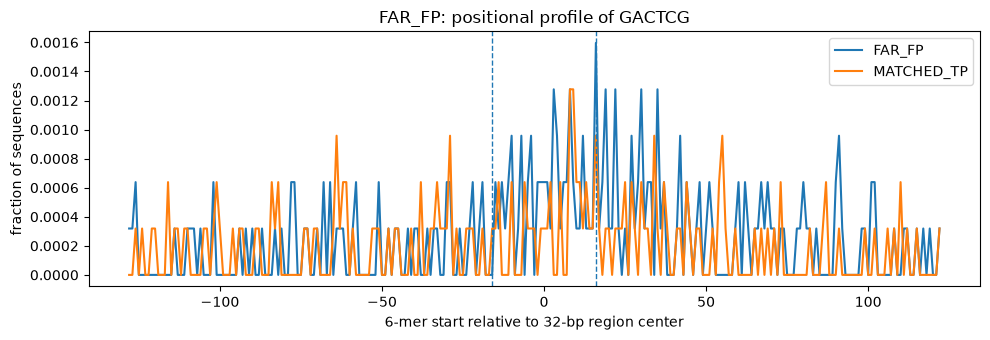

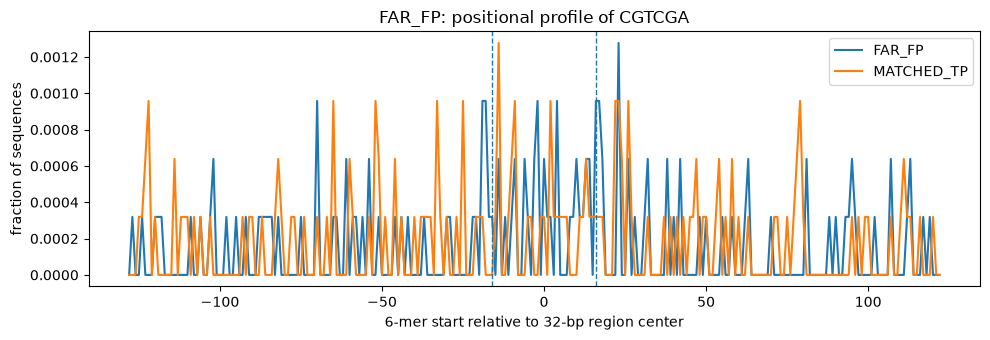

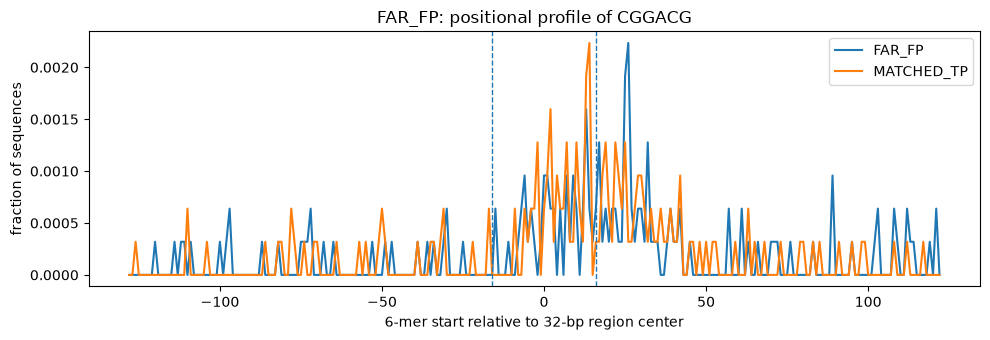

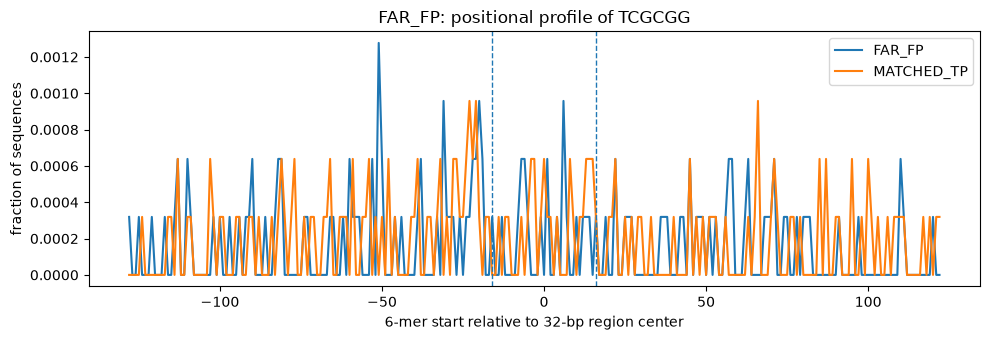

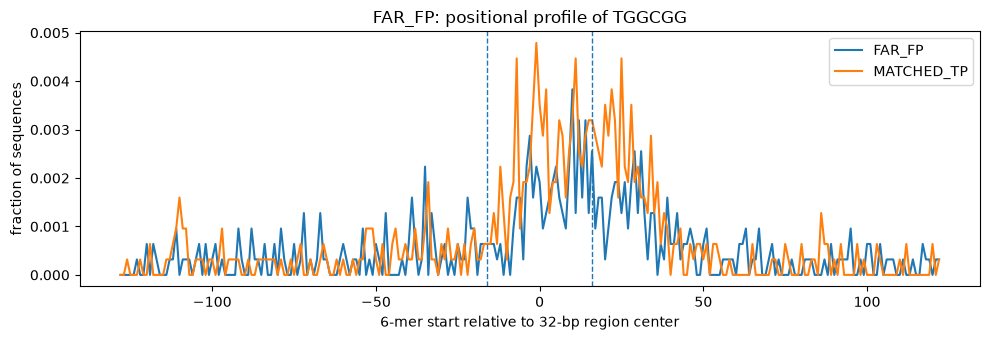

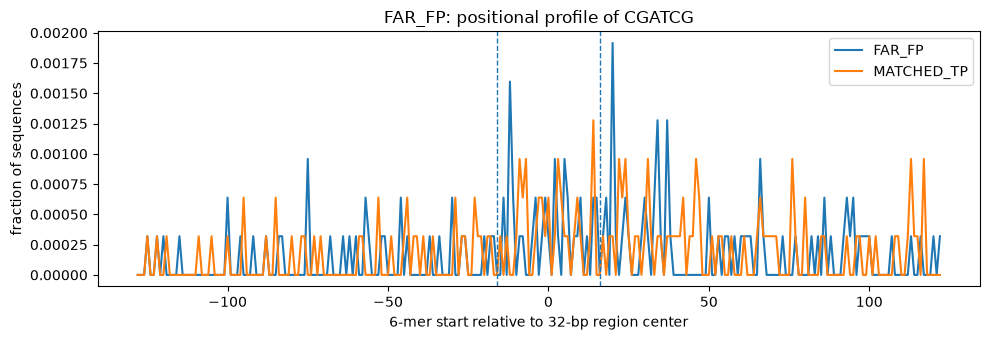


Positional motifs: ISOLATED_FP


,kmer,log2_FP_vs_EASY,log2_TP_vs_EASY,log2_FP_vs_TP
2166,GACTCG,3.630600,3.009609,0.620991
1670,CGGACG,2.929974,3.023084,-0.093109
1752,CGTCGA,2.921400,3.269323,-0.347923
3482,TCGCGG,2.821371,3.027822,-0.206451
422,ACGGCG,3.120422,2.796071,0.324351
3738,TGGCGG,2.744269,3.135368,-0.391099


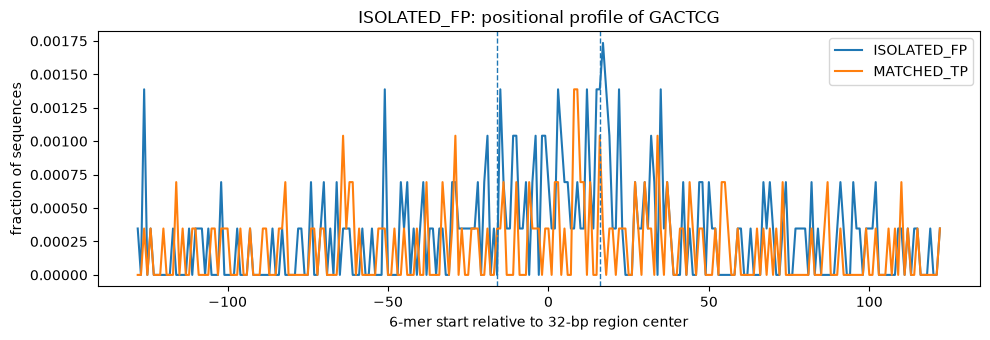

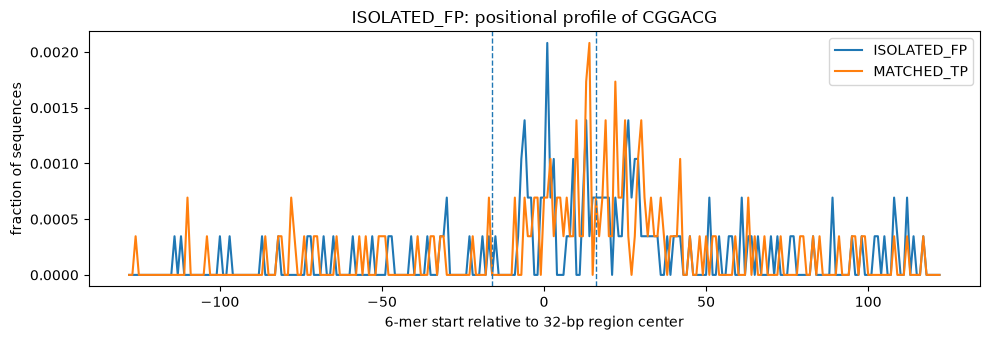

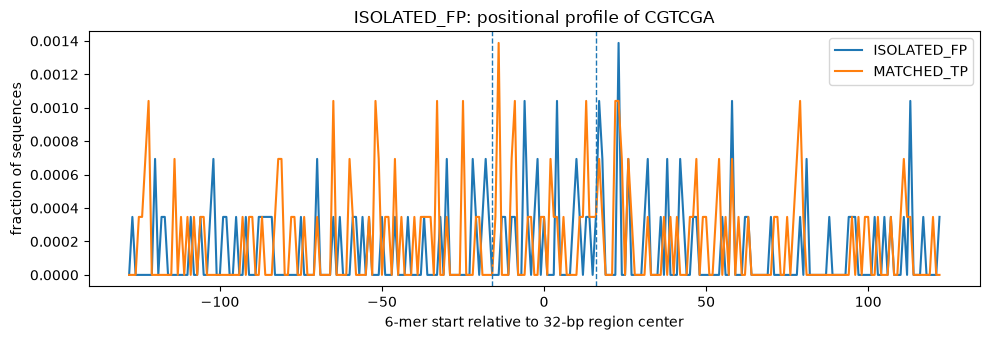

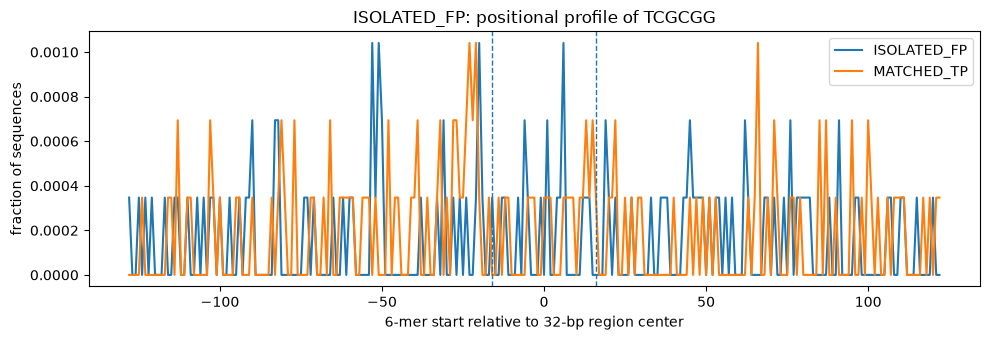

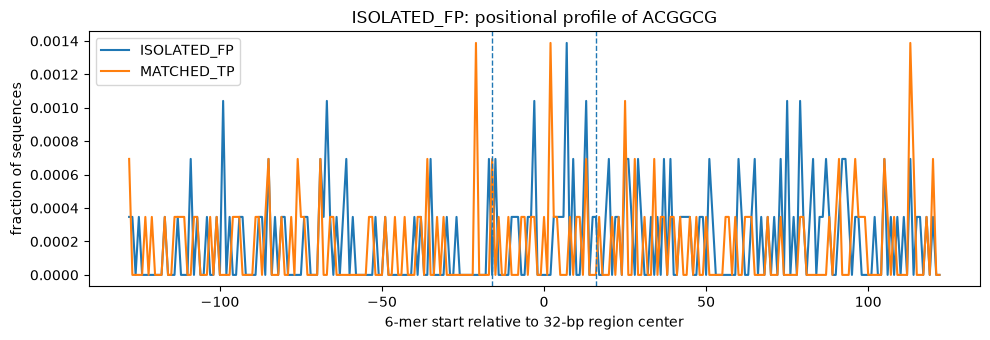

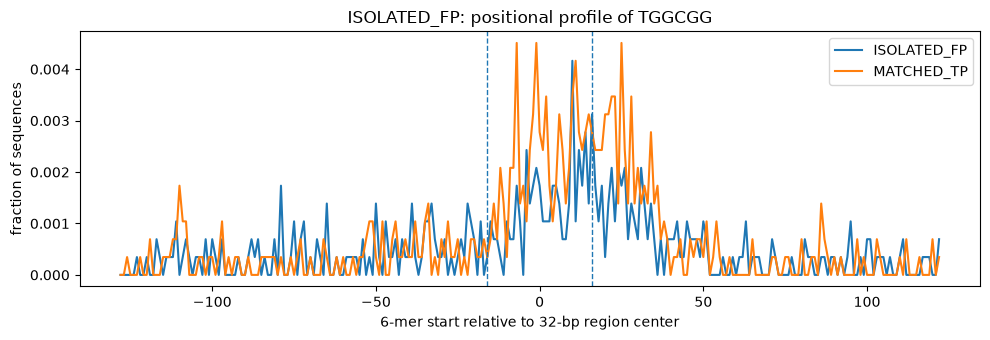

,cohort,kmer,max_abs_position_frequency_diff,mean_abs_position_frequency_diff
0,FAR_FP,GACTCG,0.001277,0.000243
1,FAR_FP,CGTCGA,0.000958,0.000230
2,FAR_FP,CGGACG,0.001916,0.000205
3,FAR_FP,TCGCGG,0.001277,0.000216
4,FAR_FP,TGGCGG,0.003193,0.000543
5,FAR_FP,CGATCG,0.001596,0.000243
6,ISOLATED_FP,GACTCG,0.001388,0.000288
7,ISOLATED_FP,CGGACG,0.001735,0.000214
8,ISOLATED_FP,CGTCGA,0.001388,0.000238
9,ISOLATED_FP,TCGCGG,0.001041,0.000229


In [41]:
# ============================================================
# POSITIONAL PROFILES OF SHARED ENRICHED 6-MERS
# ============================================================

import matplotlib.pyplot as plt


def kmer_position_profile(
    sequences,
    kmer,
):
    width = (
        CONTEXT_BP
        - len(
            kmer
        )
        + 1
    )

    profile = np.zeros(
        width,
        dtype=np.float64,
    )

    for seq in sequences:
        for pos in range(
            width
        ):
            if (
                seq[
                    pos:
                    pos
                    + len(
                        kmer
                    )
                ]
                == kmer
            ):
                profile[
                    pos
                ] += 1.0

    profile /= max(
        len(
            sequences
        ),
        1,
    )

    return profile


position_profile_rows = []

for cohort_name, pair in (
    primary_pair_frames.items()
):
    table = (
        strict_kmer_tables[
            cohort_name
        ]
    )

    shared_enriched = (
        table.loc[
            (
                table[
                    "log2_FP_vs_EASY"
                ]
                > 0
            )
            & (
                table[
                    "log2_TP_vs_EASY"
                ]
                > 0
            )
        ]
        .assign(
            shared_strength=lambda df: (
                df[
                    [
                        "log2_FP_vs_EASY",
                        "log2_TP_vs_EASY",
                    ]
                ]
                .min(
                    axis=1
                )
            )
        )
        .nlargest(
            6,
            "shared_strength",
        )
    )

    fp_sequences = (
        pair[
            "fp"
        ][
            "seq_context256"
        ]
        .tolist()
    )

    tp_sequences = (
        pair[
            "tp"
        ][
            "seq_context256"
        ]
        .tolist()
    )

    print()
    print(
        "Positional motifs:",
        cohort_name,
    )

    display(
        shared_enriched[
            [
                "kmer",
                "log2_FP_vs_EASY",
                "log2_TP_vs_EASY",
                "log2_FP_vs_TP",
            ]
        ]
    )

    for _, row in (
        shared_enriched.iterrows()
    ):
        kmer = row[
            "kmer"
        ]

        fp_profile = (
            kmer_position_profile(
                fp_sequences,
                kmer,
            )
        )

        tp_profile = (
            kmer_position_profile(
                tp_sequences,
                kmer,
            )
        )

        difference = (
            fp_profile
            - tp_profile
        )

        position_profile_rows.append({
            "cohort": (
                cohort_name
            ),
            "kmer": (
                kmer
            ),
            "max_abs_position_frequency_diff": float(
                np.max(
                    np.abs(
                        difference
                    )
                )
            ),
            "mean_abs_position_frequency_diff": float(
                np.mean(
                    np.abs(
                        difference
                    )
                )
            ),
        })

        relative_position = (
            np.arange(
                len(
                    fp_profile
                )
            )
            - (
                CONTEXT_BP
                // 2
            )
        )

        plt.figure(
            figsize=(
                10,
                3.5,
            )
        )

        plt.plot(
            relative_position,
            fp_profile,
            label=cohort_name,
        )

        plt.plot(
            relative_position,
            tp_profile,
            label="MATCHED_TP",
        )

        plt.axvline(
            -16,
            linestyle="--",
            linewidth=1,
        )

        plt.axvline(
            16,
            linestyle="--",
            linewidth=1,
        )

        plt.title(
            f"{cohort_name}: positional profile of {kmer}"
        )

        plt.xlabel(
            "6-mer start relative to 32-bp region center"
        )

        plt.ylabel(
            "fraction of sequences"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()


position_profile_summary = (
    pd.DataFrame(
        position_profile_rows
    )
)

display(
    position_profile_summary
)


In [42]:
# ============================================================
# SAVE PHASE-3 RESULTS
# ============================================================

PHASE3_DIR = (
    EXP033_RUN_DIR
    / "false_positive_study"
    / "phase3_far_fp_strict_score_control"
)

PHASE3_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

cohort_summary.to_csv(
    PHASE3_DIR
    / "far_fp_cohort_summary.csv",
    index=False,
)

score_control_quality.to_csv(
    PHASE3_DIR
    / "score_control_quality_sweep.csv",
    index=False,
)

strict_composition.to_csv(
    PHASE3_DIR
    / "strict_score_control_composition.csv",
    index=False,
)

strict_classifier_results.to_csv(
    PHASE3_DIR
    / "strict_score_control_classifier_auc.csv",
    index=False,
)

strict_kmer_summary.to_csv(
    PHASE3_DIR
    / "strict_score_control_6mer_summary.csv",
    index=False,
)

position_profile_summary.to_csv(
    PHASE3_DIR
    / "shared_6mer_position_profile_summary.csv",
    index=False,
)

far_fp.to_csv(
    PHASE3_DIR
    / "far_fp_same_strand_gt_2kb.csv",
    index=False,
)

isolated_fp.to_csv(
    PHASE3_DIR
    / "isolated_fp_any_strand_gt_2kb.csv",
    index=False,
)

for cohort_name, match in (
    primary_matches.items()
):
    pd.DataFrame({
        "fp_catalog_index": (
            match[
                "fp_idx"
            ]
        ),
        "tp_catalog_index": (
            match[
                "tp_idx"
            ]
        ),
        "fp_score": (
            scores_all[
                match[
                    "fp_idx"
                ]
            ]
        ),
        "tp_score": (
            scores_all[
                match[
                    "tp_idx"
                ]
            ]
        ),
        "fp_logit": stable_logit(
            scores_all[
                match[
                    "fp_idx"
                ]
            ]
        ),
        "tp_logit": stable_logit(
            scores_all[
                match[
                    "tp_idx"
                ]
            ]
        ),
        "logit_bin": (
            match[
                "bin_key"
            ]
        ),
    }).to_csv(
        PHASE3_DIR
        / (
            cohort_name.lower()
            + "_primary_score_control_pairs.csv"
        ),
        index=False,
    )

for cohort_name, table in (
    strict_kmer_tables.items()
):
    table.to_csv(
        PHASE3_DIR
        / (
            cohort_name.lower()
            + "_strict_6mer_enrichment.csv"
        ),
        index=False,
    )

print(
    "Saved Phase 3 to:",
    PHASE3_DIR,
)


Saved Phase 3 to: D:\Projects\EPIC\EPIC\artifacts\experiments\CNN_EXP033_BASELEVEL_RF2053_REGIONAL_32_ONLY\run_001\false_positive_study\phase3_far_fp_strict_score_control


# Что прислать после запуска

Сначала только три таблицы:

### 1. `score_control_quality`

Особенно для `bin_width_logit = 0.10`:

```text
n_pairs
retained_fraction_of_cohort
median_abs_logit_pair_diff
p95_abs_logit_pair_diff
```

### 2. `strict_classifier_results`

Нас интересуют сразу два AUC:

```text
bag_4mer_auc
position_aware_256bp_auc
```

Если второй резко выше первого — это прямой намёк на **позиционную DNA syntax**.

### 3. `strict_kmer_summary`

```text
enrichment_correlation
top50_jaccard
median_abs_log2_fp_vs_tp
```

Особенно важна строка `ISOLATED_FP`.

Если даже `ISOLATED_FP`, где нет ни одного наблюдаемого TSS любого strand в ±2 kb,
остаётся почти неотличимым от score-controlled TP по локальной последовательности,
это будет уже существенно более сильный результат, чем исходный HARD_FP анализ.
